### Five SRL behaviors (L & I embodied)

Prompts live in **`all-prompts/L_and_I_Prompt_<BEHAVIOR>.txt`** (same `[***NEW_MESSAGE***]` few-shot layout). Use **`prepare_embodied_csv_for_action(df, action, student_name)`** so the CSV matches what each prompt asserts.

| Behavior | Modalities kept (after shaping) | `Speaker:` line |
|----------|-----------------------------------|-----------------|
| **ENACTING** | gaze (Screen only), movement, action, state | No |
| **MONITORING** | same as ENACTING | No |
| **INTERACTING** | gaze, speech, state | Yes |
| **REFLECTING** | gaze, speech, gesture | Yes |
| **PLANNING** | gaze, speech, gesture | Yes |

- **Few-shot builders:** `enacting_fewshot_messages`, `monitoring_fewshot_messages`, `interacting_fewshot_messages`, `reflecting_fewshot_messages`, `planning_fewshot_messages` → each returns the prefix; append one **`{"role":"user","content": api_csv_string}`** turn.

- **Notebook layout:** **§1b Pipeline inputs** (one place to swap CSVs) → **§2 API** → **§3 ENACTING** → **§4 INTERACTING** → **§5 MONITORING** → **§6 PLANNING** → **§7 REFLECTING** → **§9 Inference pipeline** onward.




## 1. Shared — paths, prompts & CSV helper

`PROJECT_ROOT`, `PROMPTS_DIR`, `SPLIT_STRING`, `STUDENT_DAY_CSV_DIR`, `load_srl_prompt_parts`, `srl_fewshot_messages`, and `prepare_embodied_csv_for_action` — run this before any few-shot cells for the five behaviors.


In [1]:
from pathlib import Path
import re

PROJECT_ROOT = Path("/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT")

# Shared delimiter in all `all-prompts/L_and_I_Prompt_*.txt` files
SPLIT_STRING = "\n[***NEW_MESSAGE***]\n"

STUDENT_DAY_CSV_DIR = PROJECT_ROOT / "study-data-per-student-day-behavior"
PROMPTS_DIR = PROJECT_ROOT / "all-prompts"


def load_srl_prompt_parts(behavior: str) -> list:
    """Load [system, demo user, demo assistant] parts for L_and_I_Prompt_<BEHAVIOR>.txt."""
    name = (behavior or "").strip().upper()
    path = PROMPTS_DIR / f"L_and_I_Prompt_{name}.txt"
    raw = path.read_text(encoding="utf-8")

    # Normalize mixed newlines in source prompt files (CRLF/CR -> LF)
    # so SPLIT_STRING parsing is stable across editors.
    raw = raw.replace("\r\n", "\n").replace("\r", "\n")

    parts = raw.split(SPLIT_STRING)
    if len(parts) != 3:
        raise ValueError(f"{path.name}: expected 3 blocks split by SPLIT_STRING; got {len(parts)}")

    return parts


def srl_fewshot_messages(model_id: str, prompt_parts: list) -> list:
    """OpenAI: system + user + assistant. Claude: user + user + assistant."""
    mid = (model_id or "").lower()
    claude = "claude" in mid or "anthropic" in mid
    if claude:
        return [
            {"role": "user", "content": prompt_parts[0].strip()},
            {"role": "user", "content": prompt_parts[1].strip()},
            {"role": "assistant", "content": prompt_parts[2].strip()},
        ]
    return [
        {"role": "system", "content": prompt_parts[0].strip()},
        {"role": "user", "content": prompt_parts[1].strip()},
        {"role": "assistant", "content": prompt_parts[2].strip()},
    ]


def prepare_embodied_csv_for_action(df, action: str, student_name: str):
    """Normalize a modality CSV for the API.

    enacting | monitoring: drop gesture & speech; keep gaze rows only when data == "Screen" (no Speaker line).
    interacting: drop movement, action, gesture; prefix with Speaker: <student_name>.
    reflecting | planning: drop movement, action, state; prefix with Speaker: <student_name>.
    """
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")
    act = (action or "").strip().lower()
    if act not in {"enacting", "monitoring", "interacting", "reflecting", "planning"}:
        raise ValueError(
            f"Unknown action {action!r}; use enacting|monitoring|interacting|reflecting|planning"
        )

    d = df.copy().fillna("")

    # Keep only the columns used by prompts / downstream validators.
    # This matches the compact CSV format used in the working notebook.
    core_cols = [c for c in ["start_time", "end_time", "modality", "data"] if c in d.columns]
    missing = [c for c in ["start_time", "end_time", "modality", "data"] if c not in d.columns]
    if missing:
        raise ValueError(f"Input CSV missing required columns: {missing}")
    d = d[core_cols].copy()

    d["data"] = d["data"].replace("not moving", "stationary")

    if act in {"enacting", "monitoring"}:
        d = d[~d["modality"].isin(["gesture", "speech"])]
        d = d[(d["modality"] != "gaze") | (d["data"] == "Screen")]
    elif act == "interacting":
        d = d[~d["modality"].isin(["movement", "action", "gesture"])]
    elif act in {"reflecting", "planning"}:
        d = d[~d["modality"].isin(["movement", "action", "state"])]

    body = d.to_csv(index=False)
    if act in {"interacting", "reflecting", "planning"}:
        body = f"Speaker: {student_name}\n\n" + body
    return body, d


def _project_path(maybe_path) -> Path:
    p = Path(maybe_path)
    return p if p.is_absolute() else (PROJECT_ROOT / p)


def infer_student_name_from_filename(stem: str) -> str:
    m = re.search(r"Student\s+(.+?)\s+-\s+day", stem, flags=re.IGNORECASE)
    return m.group(1).strip() if m else ""


def branch_slug_from_stem(stem: str) -> str:
    s = stem.strip()
    s = re.sub(r"(?i)^L&I\s*-\s*embodied\s*-\s*", "", s)
    s = re.sub(r"(?i)\s*-\s*interacting\s*$", "", s)
    s = re.sub(r"(?i)\s*-\s*enacting\s*$", "", s)
    s = re.sub(r"(?i)\s*-\s*monitoring\s*$", "", s)
    s = re.sub(r"(?i)\s*-\s*planning\s*$", "", s)
    s = re.sub(r"(?i)\s*-\s*reflecting\s*$", "", s)
    s = re.sub(r"[^A-Za-z0-9]+", "_", s).strip("_")
    return s or "RUN"


def build_embodied_branch_pack(action: str, csv_path, student_name: str | None = None, df=None):
    """Load + normalize one embodied-behavior CSV, and derive stable naming metadata.

    Returns a dict used by each branch cell + the optional multi-model runners.
    """
    import pandas as pd

    act = (action or "").strip().lower()
    if act not in {"enacting", "monitoring", "interacting", "reflecting", "planning"}:
        raise ValueError(f"Unknown action {action!r}")

    csv_path = _project_path(csv_path)
    stem = csv_path.stem

    inferred = infer_student_name_from_filename(stem)
    student = (student_name if student_name is not None else inferred)

    if act in {"enacting", "monitoring"}:
        student_for_prepare = ""
    else:
        if not isinstance(student, str) or not student.strip():
            raise ValueError(
                f"{csv_path.name}: could not infer student name from filename; "
                f"pass student_name=... to build_embodied_branch_pack(...)"
            )
        student_for_prepare = student.strip()

    if df is None:
        d0 = pd.read_csv(csv_path).fillna("")
    else:
        d0 = df.copy().fillna("")

    api_csv, d_model = prepare_embodied_csv_for_action(d0, act, student_for_prepare)

    slug = branch_slug_from_stem(stem)
    behavior_label = act.upper()
    output_stem = f"{behavior_label}_{slug}"
    processor_label = f"{behavior_label} {slug.replace('_', ' ')}"

    demo_model_id = globals().get("DEMO_MODEL_ID") or globals().get("PREVIEW_MODEL_ID") or "gpt-5.2-v2"

    return {
        "action": act,
        "csv_path": csv_path,
        "student_name": student_for_prepare if act in {"enacting", "monitoring"} else student_for_prepare,
        "inferred_student": inferred,
        "api_csv": api_csv,
        "df_model": d_model,
        "behavior_label": behavior_label,
        "output_stem": output_stem,
        "processor_label": processor_label,
        "demo_model_id": demo_model_id,
    }


## 1b. Pipeline inputs (edit per student/day)

Put **one CSV path per behavior** here. Everything downstream (`messages*`, output stems, default segment labels) is derived automatically.

- Paths can be **absolute** or **relative to `PROJECT_ROOT`**.
- For **INTERACTING / PLANNING / REFLECTING**, filenames should include `Student <Name> - day …` so `Speaker:` can be inferred.


In [2]:
from pathlib import Path

# Used only to decide OpenAI vs Claude few-shot role layout.
DEMO_MODEL_ID = "gpt-5.2-v2"

# Optional: keep legacy notebooks happy.
PREVIEW_MODEL_ID = DEMO_MODEL_ID

PIPELINE_INPUTS = {
    "demo_model_id": DEMO_MODEL_ID,
    "enacting": "L&I - Student Mastersheet - EN-MESSI-D2.csv",
    "interacting": Path("study-data-per-student-day-behavior") / "L&I - embodied - Student Rose - day 1 - interacting.csv",
    "monitoring": Path("study-data-per-student-day-behavior") / "L&I - embodied - Student DaPaw - day 1 - monitoring.csv",
    "planning": Path("study-data-per-student-day-behavior") / "L&I - embodied - Student DaPaw - day 1 - planning.csv",
    "reflecting": Path("study-data-per-student-day-behavior") / "L&I - embodied - Student DaPaw - day 1 - reflecting.csv",
    # Keep one CSV per core behavior; optional companion runs removed.
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEMO_MODEL_ID:", DEMO_MODEL_ID)
for k in ("enacting", "interacting", "monitoring", "planning", "reflecting"):
    p = _project_path(PIPELINE_INPUTS[k])
    print(f"PIPELINE_INPUTS[{k!r}] ->", p, "exists:", p.exists())


PROJECT_ROOT: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT
DEMO_MODEL_ID: gpt-5.2-v2
PIPELINE_INPUTS['enacting'] -> /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/L&I - Student Mastersheet - EN-MESSI-D2.csv exists: True
PIPELINE_INPUTS['interacting'] -> /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student Rose - day 1 - interacting.csv exists: True
PIPELINE_INPUTS['monitoring'] -> /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - monitoring.csv exists: True
PIPELINE_INPUTS['planning'] -> /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - planning.csv exists: True
PIPELINE_INPUTS['reflecting'] -> /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - reflecting.csv exists: True


## 2. Shared — API token & headers

Run **Configuration** before `get_available_models` / `run_pipeline`.

Few-shot role layout (OpenAI vs Claude) is controlled by **`DEMO_MODEL_ID`** in **Pipeline inputs** (§1b). You can still export `PREVIEW_MODEL_ID` if you want, but it is optional.


In [ ]:
## Configuration
import os
import requests

BASE_URL = "https://prod-api.vanderbilt.ai"


if AMP_TOKEN.strip():
    os.environ["AMP_TOKEN"] = AMP_TOKEN.strip()
AMP_TOKEN = os.environ.get("AMP_TOKEN", "").strip()
if not AMP_TOKEN:
    raise RuntimeError(
        "Set AMP_TOKEN: paste into AMP_TOKEN = '' in this cell, or export AMP_TOKEN='…', then re-run."
    )

headers = {
    "Authorization": f"Bearer {AMP_TOKEN}",
    "Content-Type": "application/json",
}

## 3. ENACTING branch

Few-shot → mastersheet import → default **`messages`** (CSV path comes from **§1b Pipeline inputs**).


In [4]:
# ENACTING: few-shot from all-prompts (use with `messages` + MESSI CSV below).
prompt_split_enacting = load_srl_prompt_parts("ENACTING")


def enacting_fewshot_messages(model_id: str) -> list:
    return srl_fewshot_messages(model_id, prompt_split_enacting)



In [5]:
import pandas as pd

# ENACTING: load the CSV from PIPELINE_INPUTS, normalize, build default `messages`.
BRANCH_ENACTING = build_embodied_branch_pack("enacting", PIPELINE_INPUTS["enacting"])

DATA_PATH = BRANCH_ENACTING["csv_path"]
df = pd.read_csv(DATA_PATH).fillna("")

data_csv_string = BRANCH_ENACTING["api_csv"]
df_enacting_model = BRANCH_ENACTING["df_model"]

DEFAULT_BEHAVIOR_LABEL = BRANCH_ENACTING["behavior_label"]
OUTPUT_STEM_PREFIX = BRANCH_ENACTING["output_stem"]
AMALIA_PROCESSOR_LABEL = BRANCH_ENACTING["processor_label"]

messages = enacting_fewshot_messages(BRANCH_ENACTING["demo_model_id"]) + [
    {"role": "user", "content": data_csv_string},
]

print("ENACTING csv:", str(DATA_PATH))
print("ENACTING output_stem:", OUTPUT_STEM_PREFIX)
print("ENACTING message count:", len(messages))
print("ENACTING prompt chars:", [len(str(m.get("content", ""))) for m in messages[:3]])
print("ENACTING csv chars:", len(str(messages[-1].get("content", ""))))
df_enacting_model.head()


ENACTING csv: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/L&I - Student Mastersheet - EN-MESSI-D2.csv
ENACTING output_stem: ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2
ENACTING message count: 4
ENACTING prompt chars: [4397, 927, 6292]
ENACTING csv chars: 6067


,start_time,end_time,modality,data
0,0:00:00,,state,waterthinking
1,0:00:00,0:00:05,movement,stationary
3,0:00:06,0:00:09,movement,moving
4,0:00:07,0:04:38,gaze,Screen
5,0:00:08,0:00:14,movement,stationary


## 4. INTERACTING branch

Few-shot → per-student discourse CSV → **`messages_interacting`** (CSV path comes from **§1b Pipeline inputs**).


In [6]:
# INTERACTING: few-shot from all-prompts (use with `messages_interacting` + discourse CSV below).
prompt_split_interacting = load_srl_prompt_parts("INTERACTING")


def interacting_fewshot_messages(model_id: str) -> list:
    return srl_fewshot_messages(model_id, prompt_split_interacting)

In [7]:
# INTERACTING: load the CSV from PIPELINE_INPUTS, normalize, build `messages_interacting`.
# Few-shot prefix is defined above (**INTERACTING — few-shot from Prompt_INTERACTING.txt**); run that cell first.
BRANCH_INTERACTING = build_embodied_branch_pack("interacting", PIPELINE_INPUTS["interacting"])

api_csv_interacting = BRANCH_INTERACTING["api_csv"]
_df_inter_model = BRANCH_INTERACTING["df_model"]

DEFAULT_BEHAVIOR_LABEL_INTER = BRANCH_INTERACTING["behavior_label"]
OUTPUT_STEM_PREFIX_INTER = BRANCH_INTERACTING["output_stem"]
AMALIA_PROCESSOR_LABEL_INTER = BRANCH_INTERACTING["processor_label"]

messages_interacting = interacting_fewshot_messages(BRANCH_INTERACTING["demo_model_id"]) + [
    {"role": "user", "content": api_csv_interacting},
]

print("INTERACTING csv:", str(BRANCH_INTERACTING["csv_path"]))
print("INTERACTING output_stem:", OUTPUT_STEM_PREFIX_INTER)
print("INTERACTING message count:", len(messages_interacting))
_df_inter_model.head()


INTERACTING csv: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student Rose - day 1 - interacting.csv
INTERACTING output_stem: INTERACTING_Student_Rose_day_1
INTERACTING message count: 4


,start_time,end_time,modality,data
0,0:00:01,,speech,Teacher - Ms Hughes: Okay.
1,0:00:02,,speech,Teacher - Ms Hughes: So I want you to take a l...
2,0:00:05,0:00:10,gaze,Screen
3,0:00:05,,speech,Teacher - Ms Hughes: So what is Rose starting ...
4,0:00:08,,speech,Student - Rose: Air.


## 5. MONITORING branch

Few-shot → per-student day CSV → **`messages_monitoring`** (CSV path comes from **§1b Pipeline inputs**).


In [8]:
# MONITORING: few-shot from all-prompts (use with `messages_monitoring` + per-student day CSV below).
import pandas as pd

prompt_split_monitoring = load_srl_prompt_parts("MONITORING")


def monitoring_fewshot_messages(model_id: str) -> list:
    return srl_fewshot_messages(model_id, prompt_split_monitoring)


BRANCH_MONITORING = build_embodied_branch_pack("monitoring", PIPELINE_INPUTS["monitoring"])

api_csv_mon = BRANCH_MONITORING["api_csv"]
_df_mon_model = BRANCH_MONITORING["df_model"]

messages_monitoring = monitoring_fewshot_messages(BRANCH_MONITORING["demo_model_id"]) + [
    {"role": "user", "content": api_csv_mon},
]

print("MONITORING csv:", str(BRANCH_MONITORING["csv_path"]))
print("MONITORING output_stem:", BRANCH_MONITORING["output_stem"])
print("MONITORING message count:", len(messages_monitoring))
_df_mon_model.head()


MONITORING csv: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - monitoring.csv
MONITORING output_stem: MONITORING_Student_DaPaw_day_1
MONITORING message count: 4


,start_time,end_time,modality,data
0,0:00:05,0:00:10,gaze,Screen
1,0:00:10,0:00:15,gaze,Screen
2,0:00:15,0:00:20,gaze,Screen
3,0:00:20,0:00:25,gaze,Screen
4,0:00:23,0:00:30,movement,stationary


## 6. PLANNING branch

Few-shot → per-student day CSV → **`messages_planning`** (CSV path comes from **§1b Pipeline inputs**).


In [9]:
# PLANNING: few-shot from all-prompts (use with `messages_planning` + per-student day CSV below).
import pandas as pd

prompt_split_planning = load_srl_prompt_parts("PLANNING")


def planning_fewshot_messages(model_id: str) -> list:
    return srl_fewshot_messages(model_id, prompt_split_planning)


BRANCH_PLANNING = build_embodied_branch_pack("planning", PIPELINE_INPUTS["planning"])

api_csv_plan = BRANCH_PLANNING["api_csv"]
_df_plan_model = BRANCH_PLANNING["df_model"]

messages_planning = planning_fewshot_messages(BRANCH_PLANNING["demo_model_id"]) + [
    {"role": "user", "content": api_csv_plan},
]

print("PLANNING csv:", str(BRANCH_PLANNING["csv_path"]))
print("PLANNING output_stem:", BRANCH_PLANNING["output_stem"])
print("PLANNING message count:", len(messages_planning))
_df_plan_model.head()


PLANNING csv: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - planning.csv
PLANNING output_stem: PLANNING_Student_DaPaw_day_1
PLANNING message count: 4


,start_time,end_time,modality,data
0,0:00:01,,speech,Teacher - Ms Hughes: Okay.
1,0:00:02,,speech,Teacher - Ms Hughes: So I want you to take a l...
2,0:00:05,0:00:10,gaze,Screen
3,0:00:05,,speech,Teacher - Ms Hughes: So what is Rose starting ...
4,0:00:08,,speech,Student - Rose: Air.


## 7. REFLECTING branch

Few-shot → per-student day CSV → **`messages_reflecting`** (CSV path comes from **§1b Pipeline inputs**).


In [10]:
# REFLECTING: few-shot from all-prompts (use with `messages_reflecting` + per-student day CSV below).
import pandas as pd

prompt_split_reflecting = load_srl_prompt_parts("REFLECTING")


def reflecting_fewshot_messages(model_id: str) -> list:
    return srl_fewshot_messages(model_id, prompt_split_reflecting)


BRANCH_REFLECTING = build_embodied_branch_pack("reflecting", PIPELINE_INPUTS["reflecting"])

api_csv_refl = BRANCH_REFLECTING["api_csv"]
_df_refl_model = BRANCH_REFLECTING["df_model"]

messages_reflecting = reflecting_fewshot_messages(BRANCH_REFLECTING["demo_model_id"]) + [
    {"role": "user", "content": api_csv_refl},
]

print("REFLECTING csv:", str(BRANCH_REFLECTING["csv_path"]))
print("REFLECTING output_stem:", BRANCH_REFLECTING["output_stem"])
print("REFLECTING message count:", len(messages_reflecting))
_df_refl_model.head()


REFLECTING csv: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/study-data-per-student-day-behavior/L&I - embodied - Student DaPaw - day 1 - reflecting.csv
REFLECTING output_stem: REFLECTING_Student_DaPaw_day_1
REFLECTING message count: 4


,start_time,end_time,modality,data
0,0:00:01,,speech,Teacher - Ms Hughes: Okay.
1,0:00:02,,speech,Teacher - Ms Hughes: So I want you to take a l...
2,0:00:05,0:00:10,gaze,Screen
3,0:00:05,,speech,Teacher - Ms Hughes: So what is Rose starting ...
4,0:00:08,,speech,Student - Rose: Air.


In [68]:
# reserved


## 8. Inference pipeline

Run **Unified Inference Pipeline** once (defines the base `run_pipeline` and sets `_run_pipeline_original`). Then run **Hotfix** (thin wrapper: JSON-retry + always looks up the latest `_run_pipeline_original`). Re-run **Pipeline** after any edit to `run_pipeline`, then **Hotfix** again. Optionally run the **print** cell to confirm definitions.


In [11]:
# ===== Unified Inference Pipeline =====
import os
import re
import json
import time
import requests
import pandas as pd


def get_available_models(base_url: str, headers: dict):
    url = f"{base_url}/available_models"
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    payload = r.json()

    data = payload.get("data", {}) if isinstance(payload, dict) else {}
    models = data.get("models", []) if isinstance(data, dict) else []
    default_model = data.get("default", {}) if isinstance(data, dict) else {}

    model_ids = [m.get("id") for m in models if isinstance(m, dict) and isinstance(m.get("id"), str)]
    model_ids = list(dict.fromkeys(model_ids))
    default_id = default_model.get("id") if isinstance(default_model, dict) else None

    model_lookup = {
        m.get("id"): m for m in models
        if isinstance(m, dict) and isinstance(m.get("id"), str)
    }
    return model_ids, default_id, payload, model_lookup


def _unwrap_code_fence(text: str) -> str:
    s = text.strip()
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", s, re.IGNORECASE)
    return m.group(1).strip() if m else s


def _parse_time_to_seconds(time_str: str):
    if not isinstance(time_str, str):
        return None
    s = time_str.strip()
    if not s:
        return None

    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except ValueError:
        return None
    return None


def _seconds_to_hhmmss(seconds: float) -> str:
    total = max(0, int(round(seconds)))
    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def _normalize_time_text(time_str: str) -> str | None:
    sec = _parse_time_to_seconds(time_str)
    if sec is None:
        return None
    return _seconds_to_hhmmss(sec)


def parse_model_json_strict(text):
    """ENACTING default: optional ``` fence strip, then json.loads only (no raw_decode / regex salvage)."""
    if isinstance(text, (dict, list)):
        return text
    if not isinstance(text, str):
        return None
    s = _unwrap_code_fence(text).strip()
    try:
        return json.loads(s)
    except Exception:
        return None


def safe_parse_json(text):
    # Already-structured payload from provider.
    if isinstance(text, (dict, list)):
        return text

    if not isinstance(text, str):
        return None

    s = _unwrap_code_fence(text).strip()

    # 1) Exact JSON.
    try:
        return json.loads(s)
    except Exception:
        pass

    # 2) First valid JSON value (allows trailing text).
    try:
        decoder = json.JSONDecoder()
        obj, _ = decoder.raw_decode(s)
        return obj
    except Exception:
        pass

    # 3) Fallback object/array span parse.
    for pat in (r"\{[\s\S]*\}", r"\[[\s\S]*\]"):
        m = re.search(pat, s)
        if not m:
            continue
        cand = m.group(0).strip()
        try:
            return json.loads(cand)
        except Exception:
            try:
                obj, _ = json.JSONDecoder().raw_decode(cand)
                return obj
            except Exception:
                pass

    return None


def _salvage_segments_from_truncated(s: str) -> list:
    """Walk s char-by-char collecting balanced {}-objects that contain time_in+time_out keys.
    Stops at the first unbalanced/incomplete object so truncated responses yield as many
    complete segments as possible."""
    segments = []
    i, n = 0, len(s)
    while i < n:
        open_idx = s.find('{', i)
        if open_idx < 0:
            break
        depth, in_str, escape = 0, False, False
        j = open_idx
        while j < n:
            c = s[j]
            if escape:
                escape = False
            elif in_str:
                if c == '\\':
                    escape = True
                elif c == '"':
                    in_str = False
            else:
                if c == '"':
                    in_str = True
                elif c == '{':
                    depth += 1
                elif c == '}':
                    depth -= 1
                    if depth == 0:
                        break
            j += 1
        if depth != 0:
            # Outer brace didn't close; skip past it and keep scanning for nested segments
            i = open_idx + 1
            continue
        candidate = s[open_idx:j + 1]
        try:
            obj = json.loads(candidate)
            if isinstance(obj, dict) and 'time_in' in obj and 'time_out' in obj:
                segments.append(obj)
        except Exception:
            pass
        i = j + 1
    return segments


def parse_model_json_robust(text):
    """Lenient parser: fence-strip → strict json.loads → raw_decode → segment salvage.

    Accepts:
    * Strict JSON list  [ {...}, ... ]
    * JSON object with key "segments": {"segments": [...]}
    * Markdown-fenced JSON  ```json ... ```
    * Truncated JSON (salvages every COMPLETE segment object from a cut-off response)

    Returns a dict {"segments": [...]} or None on total failure.
    """
    if isinstance(text, (dict, list)):
        return text
    if not isinstance(text, str):
        return None
    s = _unwrap_code_fence(text).strip()

    # 1. Exact parse
    try:
        return json.loads(s)
    except Exception:
        pass

    # 2. Trailing garbage after valid JSON (e.g. model appended a comment)
    try:
        obj, _ = json.JSONDecoder().raw_decode(s)
        return obj
    except Exception:
        pass

    # 3. Regex span – pick the outermost object or array
    for pat in (r'\{[\s\S]*\}', r'\[[\s\S]*\]'):
        m = re.search(pat, s)
        if not m:
            continue
        cand = m.group(0).strip()
        try:
            return json.loads(cand)
        except Exception:
            try:
                obj, _ = json.JSONDecoder().raw_decode(cand)
                return obj
            except Exception:
                pass

    # 4. Partial salvage: extract every complete segment object even if the enclosing
    #    array/object is truncated mid-response
    salvaged = _salvage_segments_from_truncated(s)
    if salvaged:
        print(f"[parse_model_json_robust] salvaged {len(salvaged)} complete segment(s) from truncated response")
        return {"segments": salvaged, "_salvaged": True}

    return None


def normalize_output_data(data):
    """Normalize provider payload into (parsed_json_or_none, error_message_or_none, raw_text)."""
    if isinstance(data, dict):
        # Backend may wrap error in structured dict/list; coerce safely to text.
        err = data.get("error") or data.get("message")
        if err is not None:
            err_text = str(err).strip()
            if err_text:
                return None, err_text, json.dumps(data, ensure_ascii=False)
        return data, None, json.dumps(data, ensure_ascii=False)

    if isinstance(data, list):
        if len(data) == 0:
            return None, "Empty list response", "[]"
        return data, None, json.dumps(data, ensure_ascii=False)

    if isinstance(data, str):
        s = data.strip()
        if not s:
            return None, "Empty string response", ""
        if s.lower().startswith("error:"):
            return None, s, s
        parsed = safe_parse_json(s)
        return parsed, None if parsed is not None else None, s

    return None, f"Unsupported response type: {type(data).__name__}", str(data)



def _extract_screen_gaze_windows_from_csv(csv_text: str):
    df_local = pd.read_csv(pd.io.common.StringIO(csv_text)).fillna("")
    df_local["modality"] = df_local["modality"].astype(str)
    df_local["data"] = df_local["data"].astype(str)

    gaze = df_local[(df_local["modality"] == "gaze") & (df_local["data"] == "Screen")]
    windows = []
    for _, r in gaze.iterrows():
        s = _parse_time_to_seconds(str(r.get("start_time", "")))
        e = _parse_time_to_seconds(str(r.get("end_time", "")))
        if s is None or e is None:
            continue
        windows.append((s, e))
    return windows


def normalize_and_validate_segments(segments: list, csv_text: str, default_label: str = "ENACTING"):
    # Keep segments when times parse. No ordering rule (does not require time_in < time_out). Dedup + sort only.
    if not isinstance(segments, list):
        return []

    out = []
    seen = set()

    for seg in segments:
        if not isinstance(seg, dict):
            continue

        s = _parse_time_to_seconds(str(seg.get("time_in", "")))
        e = _parse_time_to_seconds(str(seg.get("time_out", "")))
        if s is None or e is None:
            continue

        row = {
            "justification": str(seg.get("justification", "")).strip(),
            "time_in": _seconds_to_hhmmss(s),
            "time_out": _seconds_to_hhmmss(e),
            "label": str(seg.get("label", default_label) or default_label),
        }

        # Exact duplicate suppression only.
        dedup_key = (row["justification"], row["time_in"], row["time_out"], row["label"])
        if dedup_key in seen:
            continue
        seen.add(dedup_key)

        out.append(row)

    out.sort(key=lambda x: (
        _parse_time_to_seconds(x.get("time_in", "")),
        _parse_time_to_seconds(x.get("time_out", "")),
    ))
    return out


def compact_segment_text(segments: list, max_words: int = 12, max_chars: int = 90, default_label: str = "ENACTING"):
    """Optional post-process: shorten each justification (used only when run_pipeline(..., compact_justifications=True))."""
    if not isinstance(segments, list):
        return []

    compacted = []
    for seg in segments:
        if not isinstance(seg, dict):
            continue

        j = str(seg.get("justification", "")).strip()
        if not j:
            j = "Verified event"

        # Keep only the first sentence-like chunk.
        j = re.split(r"(?<=[.!?])\s+", j)[0].strip()

        # Enforce short text budget.
        words = j.split()
        if len(words) > max_words:
            j = " ".join(words[:max_words])
        if len(j) > max_chars:
            j = j[:max_chars].rstrip()

        compacted.append({
            "justification": j,
            "time_in": seg.get("time_in", ""),
            "time_out": seg.get("time_out", ""),
            "label": seg.get("label", default_label),
        })

    return compacted


def sanitize_filename(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]", "_", text)


def _raw_text_from_chat_result(result: dict) -> str:
    """Best-effort extract model text from Vanderbilt-style {success, data, message, ...} envelopes."""

    def _from_leaf(obj) -> str:
        if isinstance(obj, str):
            return obj.strip()
        if isinstance(obj, dict):
            for k in ("content", "text", "output", "message", "completion", "answer", "body"):
                v = obj.get(k)
                if isinstance(v, str) and v.strip():
                    return v.strip()
            ch = obj.get("choices")
            if isinstance(ch, list) and ch and isinstance(ch[0], dict):
                msg = ch[0].get("message")
                if isinstance(msg, dict):
                    mc = msg.get("content")
                    if isinstance(mc, str) and mc.strip():
                        return mc.strip()
            return ""
        return ""

    if not isinstance(result, dict):
        return ""

    data = result.get("data", "")
    if data is None:
        data = ""

    if isinstance(data, str):
        if data.strip():
            return data.strip()
    elif isinstance(data, (dict, list)):
        leaf = _from_leaf(data) if isinstance(data, dict) else ""
        if leaf:
            return leaf
        try:
            return json.dumps(data, ensure_ascii=False)
        except Exception:
            return str(data)

    for k in ("message", "output", "content", "text"):
        v = result.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return ""


# Single set of defaults for every model_id (fair cross-model comparison).
PIPELINE_DEFAULT_MAX_ATTEMPTS = 3
PIPELINE_TRANSIENT_HTTP_SLEEP_CAP_S = 10
PIPELINE_TRANSIENT_HTTP_SLEEP_MULT_S = 5


def run_pipeline(model_id: str, messages: list, base_url: str, headers: dict,
                 output_dir: str = ".", output_stem: str | None = None,
                 max_tokens: int = 4000, temperature: float = 0,
                 max_attempts: int = PIPELINE_DEFAULT_MAX_ATTEMPTS, strict_mode: bool = True,
                 segments_only: bool = True,
                 request_timeout: float = 600,
                 model_object: dict | None = None,
                 default_segment_label: str = "ENACTING",
                 compact_justifications: bool = False):
    # Five SRL behaviors: strict JSON only — parse_model_json_strict / json.loads only.

    def prepare_messages_for_model(_model_id_inner: str, msg_list: list):
        # Claude: first block must be user, not system (instructions → user; demo CSV already user).
        mid = (_model_id_inner or "").lower()
        if not ("claude" in mid or "anthropic" in mid):
            return msg_list
        out = []
        for i, item in enumerate(msg_list):
            if not isinstance(item, dict):
                out.append(item)
                continue
            role = str(item.get("role", "user"))
            if i == 0 and role == "system":
                out.append({**item, "role": "user"})
            else:
                out.append(item)
        return out

    def coerce_messages_to_text(msg_list: list):
        out = []
        for item in msg_list:
            role = str(item.get("role", "user"))
            content = item.get("content", "")
            if isinstance(content, str):
                text = content
            elif isinstance(content, (dict, list)):
                text = json.dumps(content, ensure_ascii=False)
            else:
                text = str(content)
            out.append({"role": role, "content": text})
        return out

    model_messages = coerce_messages_to_text(prepare_messages_for_model(model_id, messages))

    csv_text = ""
    for m in reversed(model_messages):
        if m.get("role") == "user" and "start_time" in str(m.get("content", "")):
            csv_text = str(m.get("content", ""))
            break

    tag = sanitize_filename(model_id)
    _lbl = sanitize_filename((default_segment_label or "RUN").strip())
    stem = (output_stem or f"{_lbl}_{tag}").strip()
    json_path = os.path.join(output_dir, f"{stem}.json")

    # Keep max_tokens fixed across retries (do not escalate payload size on failures).
    cap = max(1, int(max_tokens))
    n_sched = max(1, int(max_attempts))
    token_schedule = [cap for _ in range(n_sched)]

    # Same request shape for every provider (model must be an object on this gateway).
    if isinstance(model_object, dict) and model_object:
        _model_field = dict(model_object)
    else:
        _model_field = {"id": model_id}

    _mid_lc = (model_id or "").lower()
    _is_claude = "claude" in _mid_lc or "anthropic" in _mid_lc

    _data_payload = {
        "temperature": temperature,
        "max_tokens": token_schedule[0],
        "dataSources": [],
        "messages": model_messages,
        "options": {
            "skipRag": True,
            "ragOnly": False,
            "model": _model_field,
        },
    }
    # Some gateway paths return success=True with empty `data` when json_object + Claude/Bedrock mismatch.
    if not _is_claude:
        _data_payload["response_format"] = {"type": "json_object"}

    payload = {"data": _data_payload}

    last_error = None
    for attempt in range(1, max_attempts + 1):
        token_idx = min(attempt - 1, len(token_schedule) - 1)
        payload["data"]["max_tokens"] = token_schedule[token_idx]

        if attempt == 1:
            _om = payload["data"]["options"].get("model")
            print(
                "[run_pipeline] options.model",
                type(_om).__name__,
                _om if isinstance(_om, str) else (list(_om.keys()) if isinstance(_om, dict) else _om),
            )

        chat_url = f"{base_url.rstrip('/')}/chat"
        _req_to = float(request_timeout)
        print(
            f"[run_pipeline][attempt {attempt}] POST {chat_url!r} | "
            f"requests timeout={_req_to}s (one value applies to connect+read) | "
            "not boto3 Bedrock in-notebook; HTTPS to your gateway only"
        )

        response = requests.post(chat_url, headers=headers, json=payload, timeout=_req_to)
        if response.status_code >= 400:
            body_text = response.text[:1000]
            print(f"[attempt {attempt}] HTTP {response.status_code} body:", body_text)
            if response.status_code == 504:
                _hk = ("Server", "Via", "x-amzn-RequestId", "x-amzn-ErrorType", "x-amz-apigw-id", "Date")
                _hd = {k: response.headers.get(k) for k in _hk if response.headers.get(k)}
                print(
                    f"[attempt {attempt}] 504: received HTTP response from server "
                    f"(not requests.exceptions.ReadTimeout at {_req_to}s). "
                    "Typical cause: API Gateway/Lambda/proxy integration timeout < model latency. "
                    f"Header subset: {_hd}"
                )
            last_error = RuntimeError(f"HTTP {response.status_code}: {body_text}")
            if response.status_code in (502, 503, 504, 529) and attempt < max_attempts:
                wait_s = min(PIPELINE_TRANSIENT_HTTP_SLEEP_CAP_S, PIPELINE_TRANSIENT_HTTP_SLEEP_MULT_S * attempt)
                print(f"[attempt {attempt}] transient HTTP {response.status_code}; sleeping {wait_s}s then retry")
                time.sleep(wait_s)
            continue

        result = response.json()

        print(f"[attempt {attempt}] max_tokens:", payload["data"]["max_tokens"])
        print(f"[attempt {attempt}] message_count:", len(payload["data"]["messages"]))
        print(f"[attempt {attempt}] result keys:", list(result.keys()) if isinstance(result, dict) else type(result).__name__)
        print(f"[attempt {attempt}] result.success:", result.get("success") if isinstance(result, dict) else None)
        print(f"[attempt {attempt}] repr(result.data):", repr(result.get("data")) if isinstance(result, dict) else None)

        if not isinstance(result, dict) or not result.get("success"):
            last_error = RuntimeError(f"Amplify returned failure: {result}")
            continue

        raw_data = result.get("data", "")
        if isinstance(raw_data, (dict, list)):
            raw_text = json.dumps(raw_data, ensure_ascii=False)
        else:
            raw_text = str(raw_data).strip()

        if not raw_text:
            # Some gateway paths return success=True with empty data but put text in `message`.
            msg_fallback = result.get("message", "") if isinstance(result, dict) else ""
            raw_text = str(msg_fallback).strip() if msg_fallback is not None else ""
            if raw_text:
                print(f"[attempt {attempt}] data empty -> using result.message fallback")

        if not raw_text:
            # Treat empty successful payload as a soft failure and retry this attempt budget.
            print(f"[attempt {attempt}] empty payload (success=True but no data/message)")
            last_error = RuntimeError(f"Empty response for {model_id}")
            continue

        if raw_text.lower().startswith("error:"):
            last_error = RuntimeError(raw_text)
            continue

        if strict_mode:
            parsed_json = parse_model_json_strict(raw_text)
            if parsed_json is None:
                last_error = RuntimeError(f"Strict mode: invalid JSON for {model_id}")
                continue
        else:
            parsed_json = parse_model_json_robust(raw_text)
            if isinstance(parsed_json, dict):
                parsed_json.pop("_salvaged", None)  # strip internal marker
            if parsed_json is None:
                last_error = RuntimeError(f"Could not parse JSON for {model_id}")
                continue

        if isinstance(parsed_json, dict) and "segments" in parsed_json:
            segments = parsed_json.get("segments", [])
        elif isinstance(parsed_json, list):
            segments = parsed_json
        else:
            segments = []

        if not isinstance(segments, list):
            segments = []

        segments = normalize_and_validate_segments(segments, csv_text, default_segment_label)
        if compact_justifications:
            segments = compact_segment_text(segments, default_label=default_segment_label)

        rule_based = False

        out_obj = {"segments": segments}
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(out_obj, f, indent=2, ensure_ascii=False)

        return {
            "json_path": json_path,
            "segment_count": len(segments),
            "rule_based": rule_based,
        }

    if last_error is not None:
        raise last_error
    raise RuntimeError(f"run_pipeline failed for {model_id} after {max_attempts} attempt(s)")


# Delegate for optional thin wrapper in the next cell — refreshed every time you re-run this cell.
_run_pipeline_original = run_pipeline


In [12]:
if "run_pipeline" not in globals():
    raise RuntimeError("Run Unified Inference Pipeline first (defines run_pipeline).")

if "_run_pipeline_original" not in globals():
    raise RuntimeError(
        "Re-run Unified Inference Pipeline to the end — it sets `_run_pipeline_original = run_pipeline`."
    )


def run_pipeline(model_id: str, messages: list, base_url: str, headers: dict,
                 output_dir: str = ".", output_stem: str | None = None,
                 max_tokens: int = 4000, temperature: float = 0,
                 max_attempts: int = 6,
                 strict_mode: bool = True,
                 segments_only: bool = True,
                 request_timeout: float = 600,
                 model_object: dict | None = None,
                 default_segment_label: str = "ENACTING",
                 compact_justifications: bool = False):
    """Thin wrapper: delegates to globals()[\"_run_pipeline_original\"] each call (Pipeline cell refreshes it)."""

    def _call(mtok: int):
        impl = globals()["_run_pipeline_original"]
        return impl(
            model_id=model_id,
            messages=messages,
            base_url=base_url,
            headers=headers,
            output_dir=output_dir,
            output_stem=output_stem,
            max_tokens=mtok,
            temperature=temperature,
            max_attempts=max_attempts,
            strict_mode=strict_mode,
            segments_only=segments_only,
            request_timeout=request_timeout,
            model_object=model_object,
            default_segment_label=default_segment_label,
            compact_justifications=compact_justifications,
        )

    mtok0 = int(max_tokens)
    try:
        return _call(mtok0)
    except RuntimeError as e:
        msg = str(e)
        if strict_mode and ("Strict mode: invalid JSON" in msg):
            retry_tokens = min(max(mtok0 * 2, 16000), 128000)
            if retry_tokens > mtok0:
                return _call(retry_tokens)
        raise


print("Hotfix cell: thin run_pipeline wrapper — re-run Unified Inference Pipeline after editing the base run_pipeline.")


Hotfix cell: thin run_pipeline wrapper — re-run Unified Inference Pipeline after editing the base run_pipeline.


In [13]:
print("run_pipeline defined from:", run_pipeline.__code__.co_filename)
print("normalize_output_data exists:", "normalize_output_data" in globals())

run_pipeline defined from: /var/folders/kz/_0d2ww4n3wx819j1cz_zzvtw0000gn/T/ipykernel_32700/3587490536.py
normalize_output_data exists: True


## Unified multi-behavior model pipeline

Run one configurable batch across any subset of the five behaviors (`enacting`, `interacting`, `monitoring`, `planning`, `reflecting`).

You only maintain input files in `PIPELINE_INPUTS`; this runner reuses each branch's prebuilt `messages_*` and metadata (`output_stem`, label).


In [20]:
# Unified runner for ENACTING/INTERACTING/MONITORING/PLANNING/REFLECTING.
# Prereqs: run branch cells first so BRANCH_* + messages_* are defined, and run pipeline cells.
RUN_MULTI_BEHAVIOR_BATCH = True  # set True to execute

BATCH_BEHAVIORS = ["enacting"]  # e.g. add "interacting", "monitoring", ... for full batch

# API cost: BATCH_MODELS_SINGLE = one id to run only that model; None = use full BATCH_MODELS list.
BATCH_MODELS_SINGLE = "o3"  # ENACTING with o3 only; stem ends with _o3 + BATCH_OUTPUT_STEM_SUFFIX
# Skip models already completed (case-insensitive id match). Use [] when nothing to skip.
BATCH_MODELS_SKIP = []

BATCH_MODELS = [
    "us.anthropic.claude-sonnet-4-5-20250929-v1:0",
    "o3",
    "gpt-5.2-v2",
    "gpt-5.2-v3",
    "us.anthropic.claude-haiku-4-5-20251001-v1:0",
]
if BATCH_MODELS_SINGLE:
    _solo = str(BATCH_MODELS_SINGLE).strip()
    _solo_l = _solo.lower()
    _all_models = list(BATCH_MODELS)
    BATCH_MODELS = [m for m in BATCH_MODELS if isinstance(m, str) and m.strip().lower() == _solo_l]
    if not BATCH_MODELS:
        raise ValueError(
            f"BATCH_MODELS_SINGLE={_solo!r} matched none of configured models: {_all_models}"
        )
    print("BATCH_MODELS_SINGLE active -> models:", BATCH_MODELS)

if BATCH_MODELS_SKIP:
    _skip_l = {str(x).strip().lower() for x in BATCH_MODELS_SKIP if isinstance(x, str) and str(x).strip()}
    _before_skip = list(BATCH_MODELS)
    BATCH_MODELS = [m for m in BATCH_MODELS if isinstance(m, str) and m.strip().lower() not in _skip_l]
    if not BATCH_MODELS:
        raise ValueError(
            f"BATCH_MODELS_SKIP removed all models; before={_before_skip!r}, skip={BATCH_MODELS_SKIP!r}"
        )
    print("BATCH_MODELS_SKIP active -> models:", BATCH_MODELS)

BATCH_MAX_TOKENS = 6000
BATCH_MAX_ATTEMPTS = int(globals().get("MAX_ATTEMPTS", globals().get("PIPELINE_DEFAULT_MAX_ATTEMPTS", 3)))
BATCH_OUTPUT_DIR = ""
BATCH_CHUNK_MINUTES = 30
BATCH_OUTPUT_STEM_SUFFIX = "_latest_index_v5"  # -> ..._o3_latest_index_v5.json (TEMPERATURE=0 in run_pipeline)
BATCH_OUTPUT_FILE_INDICES = [0]  # e.g. [0,1] -> ..._suffix_ix0.json / _ix1.json; [0] alone -> no _ix in filename


def _chunk_api_csv_by_minutes(csv_text: str, chunk_minutes: int = 12):
    if not isinstance(csv_text, str) or not csv_text.strip():
        return []

    df_chunk = pd.read_csv(pd.io.common.StringIO(csv_text)).fillna("")
    if "start_time" not in df_chunk.columns:
        return [csv_text]

    df_chunk["_start_s"] = df_chunk["start_time"].map(_parse_time_to_seconds)
    df_chunk = df_chunk.dropna(subset=["_start_s"]).copy()
    if df_chunk.empty:
        return [csv_text]

    span_s = max(60, int(chunk_minutes) * 60)
    t0 = int(df_chunk["_start_s"].min())
    chunks = []
    while True:
        t1 = t0 + span_s
        part = df_chunk[(df_chunk["_start_s"] >= t0) & (df_chunk["_start_s"] < t1)].copy()
        if not part.empty:
            part = part.drop(columns=["_start_s"], errors="ignore")
            chunks.append(part.to_csv(index=False))
        if t1 > int(df_chunk["_start_s"].max()):
            break
        t0 = t1

    return chunks or [csv_text]


def _merge_segment_runs(segment_runs: list, default_label: str = "ENACTING"):
    merged = []
    for segs in segment_runs:
        if isinstance(segs, list):
            merged.extend(segs)
    return normalize_and_validate_segments(merged, csv_text="", default_label=default_label)

def _resolve_catalog_model_id(logical_id: str, catalog_ids: list):
    """Map notebook model id to one returned by /available_models (GPT-5.2 slug aliases)."""
    if not isinstance(logical_id, str) or not isinstance(catalog_ids, list):
        return None
    want = logical_id.strip()
    if not want:
        return None
    by_l = {str(m).strip().lower(): str(m) for m in catalog_ids if isinstance(m, str) and str(m).strip()}
    wl = want.lower()
    if wl in by_l:
        return by_l[wl]
    if wl in {"gpt-5.2-v2", "gpt-5.2-v3", "gpt-5.2"} or wl.startswith("gpt-5.2"):
        pool = [str(m) for m in catalog_ids if isinstance(m, str) and ("gpt" in m.lower() and "5.2" in m.lower())]
        if not pool:
            return None
        if wl == "gpt-5.2-v3" or (wl.startswith("gpt-5.2") and wl.endswith("v3")):
            v3 = [m for m in pool if "v3" in m.lower()]
            if v3:
                return sorted(v3, key=len, reverse=True)[0]
        if wl == "gpt-5.2-v2" or (wl.startswith("gpt-5.2") and wl.endswith("v2")):
            v2 = [m for m in pool if "v2" in m.lower()]
            if v2:
                return sorted(v2, key=len, reverse=True)[0]
        plain = [m for m in pool if "v2" not in m.lower() and "v3" not in m.lower()]
        if plain:
            return sorted(plain, key=len, reverse=True)[0]
        return sorted(pool, key=len, reverse=True)[0]
    return None

if not RUN_MULTI_BEHAVIOR_BATCH:
    print("Skip multi-behavior batch: set RUN_MULTI_BEHAVIOR_BATCH = True to run.")
else:
    if "get_available_models" not in globals() or "run_pipeline" not in globals():
        raise RuntimeError("Run BASE_URL/headers and Unified Inference Pipeline cells first.")

    behavior_registry = {
        "enacting": {
            "branch": "BRANCH_ENACTING",
            "messages": "messages",
        },
        "interacting": {
            "branch": "BRANCH_INTERACTING",
            "messages": "messages_interacting",
        },
        "monitoring": {
            "branch": "BRANCH_MONITORING",
            "messages": "messages_monitoring",
        },
        "planning": {
            "branch": "BRANCH_PLANNING",
            "messages": "messages_planning",
        },
        "reflecting": {
            "branch": "BRANCH_REFLECTING",
            "messages": "messages_reflecting",
        },
    }

    available_model_ids, default_model_id, _payload, available_model_lookup = get_available_models(BASE_URL, headers)

    reports_all = []
    for behavior in BATCH_BEHAVIORS:
        key = str(behavior).strip().lower()
        if key not in behavior_registry:
            print("Skip unknown behavior:", behavior)
            continue

        reg = behavior_registry[key]
        branch_obj = globals().get(reg["branch"])
        msg_list = globals().get(reg["messages"])
        if not isinstance(branch_obj, dict) or not isinstance(msg_list, list):
            raise RuntimeError(
                f"Missing {reg['branch']} or {reg['messages']}. Run the {key.upper()} branch cell first."
            )

        stem_prefix = branch_obj["output_stem"]
        default_label = branch_obj["behavior_label"]

        print(f"\n===== {key.upper()} =====")
        for mid in BATCH_MODELS:
            if not isinstance(mid, str) or not str(mid).strip():
                print("Skip bad model entry:", mid)
                continue
            api_mid = _resolve_catalog_model_id(mid, available_model_ids)
            if api_mid is None:
                print("Skip model (not offered):", mid)
                continue
            if api_mid != str(mid).strip():
                print("[batch] resolved model id:", repr(str(mid).strip()), "->", repr(api_mid))

            _catalog_model = available_model_lookup.get(api_mid)
            if not isinstance(_catalog_model, dict):
                _catalog_model = None
            if _catalog_model is None:
                print("[batch] no /available_models dict for", repr(mid), "-> run_pipeline uses minimal {id: ...}")

            if "claude-sonnet" in mid:
                model_tag = "Claude_sonnet_4_5"
            elif "claude-haiku" in mid:
                model_tag = "Claude_haiku_4_5"
            else:
                model_tag = mid.replace("-", "_").replace(".", "_")

            csv_text = ""
            for _m in reversed(msg_list):
                if isinstance(_m, dict) and _m.get("role") == "user" and "start_time" in str(_m.get("content", "")):
                    csv_text = str(_m.get("content", ""))
                    break
            chunks = _chunk_api_csv_by_minutes(csv_text, chunk_minutes=BATCH_CHUNK_MINUTES)
            print(f"chunk_minutes={BATCH_CHUNK_MINUTES}, chunks={len(chunks)}, max_tokens={BATCH_MAX_TOKENS}, max_attempts={BATCH_MAX_ATTEMPTS}")

            import tempfile

            _file_indices = globals().get("BATCH_OUTPUT_FILE_INDICES", [0])
            for _batch_out_ix in _file_indices:
                _stem_suffix_base = str(globals().get("BATCH_OUTPUT_STEM_SUFFIX", "") or "").strip()
                _fi_list = list(_file_indices)
                if len(_fi_list) == 1:
                    _stem_suffix = _stem_suffix_base or ""
                else:
                    _stem_suffix = f"{_stem_suffix_base}_ix{_batch_out_ix}" if _stem_suffix_base else f"_ix{_batch_out_ix}"
                out_stem = f"{stem_prefix}_{model_tag}{_stem_suffix}"
                print(f"\n=== {out_stem} ({api_mid}) ===")

                chunk_segments = []
                with tempfile.TemporaryDirectory(prefix=f"llm_chunks_{sanitize_filename(out_stem)}_") as _chunk_dir:
                    for ci, chunk_csv in enumerate(chunks, start=1):
                        chunk_messages = [
                            ({**m, "content": chunk_csv} if isinstance(m, dict) and m.get("role") == "user" and "start_time" in str(m.get("content", "")) else m)
                            for m in msg_list
                        ]
                        chunk_stem = f"{out_stem}_chunk_{ci:03d}"
                        print(f"  - chunk {ci}/{len(chunks)} (temp only) -> {chunk_stem}")
                        r_chunk = run_pipeline(
                            model_id=api_mid,
                            messages=chunk_messages,
                            base_url=BASE_URL,
                            headers=headers,
                            output_dir=_chunk_dir,
                            output_stem=chunk_stem,
                            max_tokens=BATCH_MAX_TOKENS,
                            temperature=0,
                            max_attempts=BATCH_MAX_ATTEMPTS,
                            strict_mode=True,
                            segments_only=True,
                            model_object=_catalog_model,
                            default_segment_label=default_label,
                        )
                        with open(r_chunk["json_path"], "r", encoding="utf-8") as _f:
                            _obj = json.load(_f)
                        chunk_segments.append(_obj.get("segments", []))

                merged_segments = _merge_segment_runs(chunk_segments, default_label=default_label)
                final_path = os.path.join(BATCH_OUTPUT_DIR or ".", f"{out_stem}.json")
                with open(final_path, "w", encoding="utf-8") as _f:
                    json.dump({"segments": merged_segments}, _f, indent=2, ensure_ascii=False)

                r = {
                    "json_path": final_path,
                    "segment_count": len(merged_segments),
                    "rule_based": False,
                    "model_id": api_mid,
                    "chunks": len(chunks),
                }
                reports_all.append({"behavior": key, **r})
                print("Saved final (chunk files were temp only):", r["json_path"], "segments:", r.get("segment_count"), "chunks:", r.get("chunks"))

    reports_all


BATCH_MODELS_SINGLE active -> models: ['o3']

===== ENACTING =====
chunk_minutes=30, chunks=1, max_tokens=6000, max_attempts=3

=== ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_o3_latest_index_v5 (o3) ===
  - chunk 1/1 (temp only) -> ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_o3_latest_index_v5_chunk_001
[run_pipeline] options.model dict ['id', 'name', 'description', 'inputContextWindow', 'outputTokenLimit', 'supportsImages', 'supportsVideo', 'supportsImageGeneration', 'supportsReasoning', 'provider', 'supportsSystemPrompts', 'systemPrompt', 'inputTokenCost', 'outputTokenCost', 'inputCachedTokenCost', 'inputWriteCachedTokenCost']
[run_pipeline][attempt 1] POST 'https://prod-api.vanderbilt.ai/chat' | requests timeout=600.0s (one value applies to connect+read) | not boto3 Bedrock in-notebook; HTTPS to your gateway only
[attempt 1] max_tokens: 6000
[attempt 1] message_count: 4
[attempt 1] result keys: ['success', 'message', 'data']
[attempt 1] result.success: True
[attempt 1] repr(resul

,base_model,file_variant,v,file,n_segments,total_duration_min
0,Claude_haiku_4_5,default,1,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,141,193.7167
1,Claude_haiku_4_5,default,2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,55,56.7833
2,Claude_haiku_4_5,default,3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,130,177.1167
3,Claude_haiku_4_5,default,4,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,25,10.8667
4,Claude_haiku_4_5,default,5,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,133,193.1500
5,Claude_sonnet_4_5,default,1,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,134,189.1000
6,Claude_sonnet_4_5,default,2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,134,189.1833
7,Claude_sonnet_4_5,default,3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,140,190.4667
8,Claude_sonnet_4_5,default,4,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,135,188.4500
9,Claude_sonnet_4_5,default,5,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,135,190.2333


,base_model,file_variant,median_n_segments,mean_n_segments,median_total_min,mean_total_min
0,Claude_haiku_4_5,default,130,96.8,177.1167,126.32668
1,Claude_sonnet_4_5,default,135,135.6,189.1833,189.48666
2,gpt_5_2,default,134,86.0,187.1833,115.64334
3,o3,default,18,16.8,5.4833,5.62332
4,o3,latest_index,23,16.8,6.7333,129.49000
5,o3,new_index,26,27.4,6.8333,10.41000


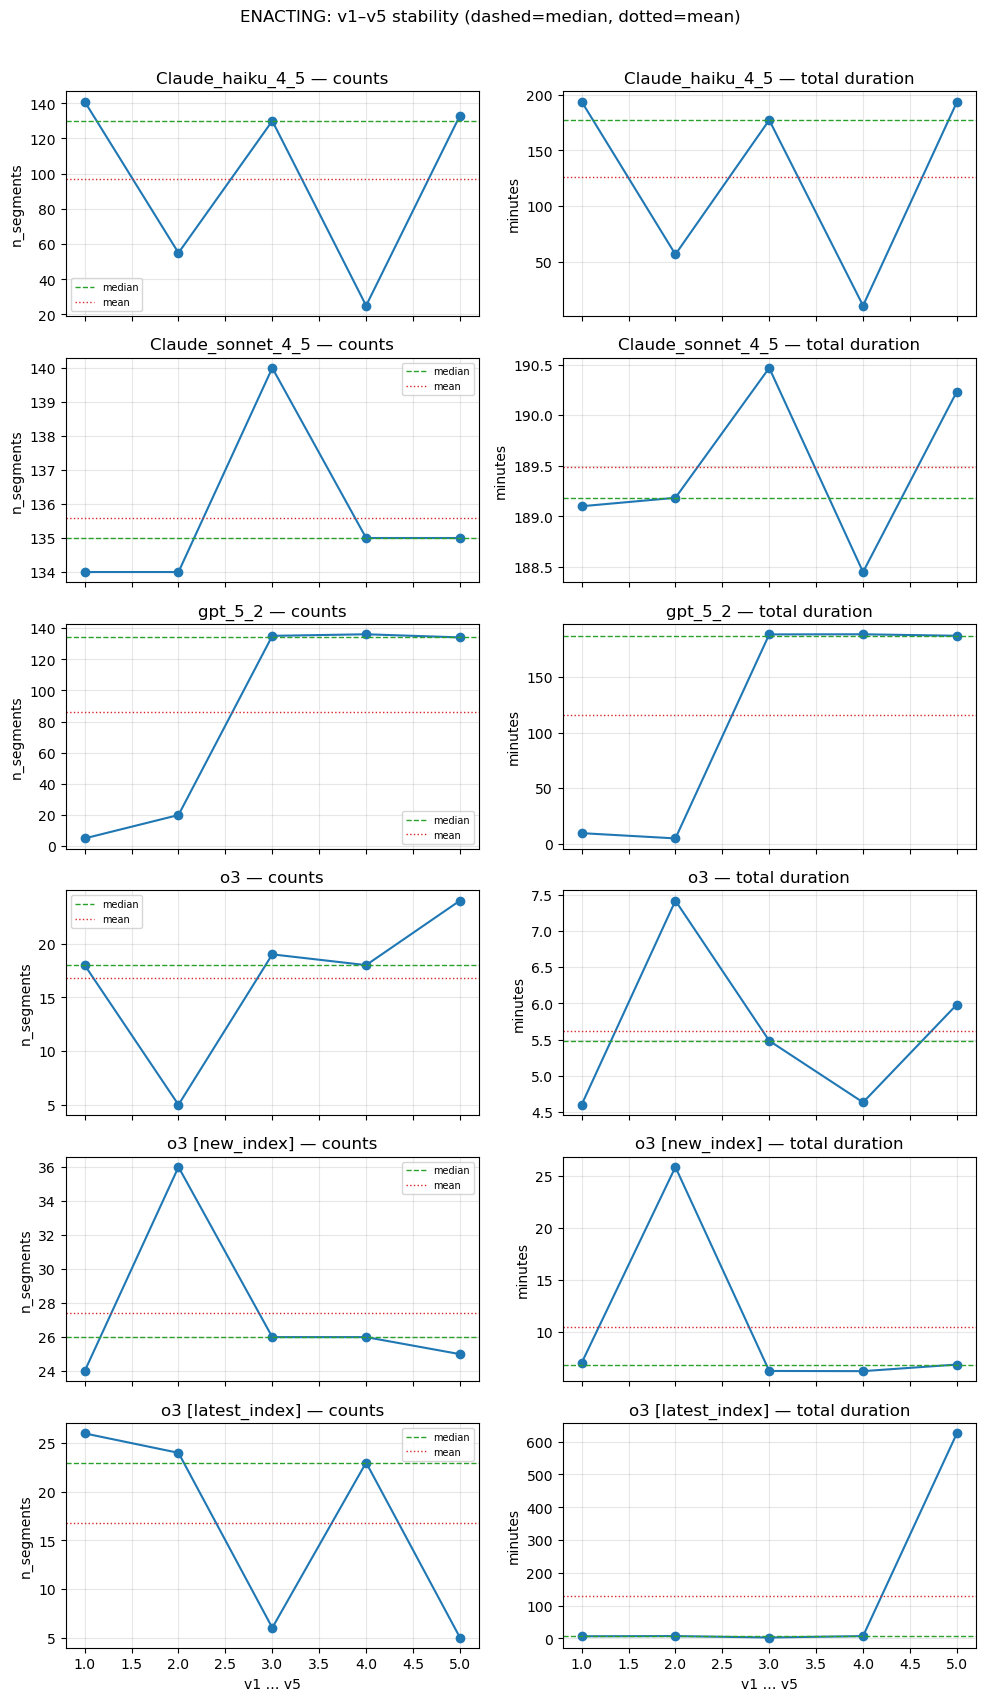

Scan: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT


In [21]:
# ENACTING v1–v5: same base model, five runs — segment count & total ENACTING duration; median/mean + plots.
# Run after Unified batch. Matches plain v1–v5, `*_new_index`, and `*_latest_index_v1..v5` (o3 × 3 variants).

from pathlib import Path
import json
import re
import statistics

_root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
_out = globals().get("BATCH_OUTPUT_DIR", "")
_scan = Path(_out) if str(_out).strip() else _root
if not _scan.is_absolute():
    _scan = _root / _scan

if "BRANCH_ENACTING" not in globals() or not isinstance(BRANCH_ENACTING, dict):
    raise RuntimeError("Run ENACTING branch cell first (BRANCH_ENACTING).")

_stem = str(BRANCH_ENACTING["output_stem"]).strip()
_pat_latest = re.compile("^" + re.escape(_stem) + r"_(?P<base>.+)_latest_index_v(?P<vn>[1-5])\.json$")
_pat_new = re.compile("^" + re.escape(_stem) + r"_(?P<base>.+)_v(?P<vn>[1-5])_new_index\.json$")
_pat_plain = re.compile("^" + re.escape(_stem) + r"_(?P<base>.+)_v(?P<vn>[1-5])\.json$")


def _match_enacting_v_file(name: str):
    for pat, variant in ((_pat_latest, "latest_index"), (_pat_new, "new_index"), (_pat_plain, "default")):
        m = pat.match(name)
        if m:
            return m.group("base"), variant, int(m.group("vn"))
    return None


def _dur_sum_s(path: Path):
    obj = json.loads(path.read_text(encoding="utf-8"))
    segs = obj.get("segments") if isinstance(obj, dict) else None
    if not isinstance(segs, list):
        return 0, 0.0
    fn = globals().get("_parse_time_to_seconds")
    total = 0.0
    for s in segs:
        if not isinstance(s, dict) or not callable(fn):
            continue
        a, b = fn(str(s.get("time_in") or "")), fn(str(s.get("time_out") or ""))
        if a is not None and b is not None and b >= a:
            total += float(b - a)
    return len(segs), total


_rows = []
for p in sorted(_scan.glob(_stem + "_*.json")):
    if not p.is_file() or "_chunk_" in p.name:
        continue
    parsed = _match_enacting_v_file(p.name)
    if not parsed:
        continue
    _bm, _fv, _vn = parsed
    n, secs = _dur_sum_s(p)
    _rows.append(
        {
            "base_model": _bm,
            "file_variant": _fv,
            "v": _vn,
            "file": p.name,
            "n_segments": n,
            "total_duration_min": round(secs / 60.0, 4),
        }
    )

if not _rows:
    print("No v1–v5 ENACTING JSON matched stem", repr(_stem), "(plain / new_index / latest_index) under", _scan.resolve())
else:
    import pandas as pd

    df = (
        pd.DataFrame(_rows)
        .sort_values(["base_model", "file_variant", "v"])
        .reset_index(drop=True)
    )
    summ = []
    for (bm, fv), g in df.groupby(["base_model", "file_variant"]):
        ns = g["n_segments"].tolist()
        dm = g["total_duration_min"].tolist()
        summ.append(
            {
                "base_model": bm,
                "file_variant": fv,
                "median_n_segments": statistics.median(ns),
                "mean_n_segments": statistics.mean(ns),
                "median_total_min": statistics.median(dm),
                "mean_total_min": statistics.mean(dm),
            }
        )
    sdf = pd.DataFrame(summ).sort_values(["base_model", "file_variant"]).reset_index(drop=True)
    display(df)
    display(sdf)
    try:
        import matplotlib.pyplot as plt

        _plot_order = {
            ("Claude_haiku_4_5", "default"): 0,
            ("Claude_sonnet_4_5", "default"): 1,
            ("gpt_5_2", "default"): 2,
            ("o3", "default"): 3,
            ("o3", "new_index"): 4,
            ("o3", "latest_index"): 5,
        }
        _pairs = df[["base_model", "file_variant"]].drop_duplicates()
        series_keys = sorted(
            [tuple(x) for x in _pairs.to_numpy()],
            key=lambda k: (_plot_order.get(k, 100), str(k[0]), str(k[1])),
        )
        xs = list(range(1, 6))
        nrows = max(1, len(series_keys))
        fig, axes = plt.subplots(nrows, 2, figsize=(10, 2.8 * nrows), sharex=True)
        if nrows == 1:
            axes = axes.reshape(1, 2)
        for i, (bm, fv) in enumerate(series_keys):
            g = df[(df["base_model"] == bm) & (df["file_variant"] == fv)].sort_values("v")
            ns = g["n_segments"].tolist()
            dm = g["total_duration_min"].tolist()
            if fv == "new_index":
                _ttl = f"{bm} [new_index]"
            elif fv == "latest_index":
                _ttl = f"{bm} [latest_index]"
            else:
                _ttl = str(bm)
            axes[i, 0].plot(xs, ns, marker="o")
            axes[i, 0].axhline(statistics.median(ns), color="C2", linestyle="--", linewidth=1, label="median")
            axes[i, 0].axhline(statistics.mean(ns), color="C3", linestyle=":", linewidth=1, label="mean")
            axes[i, 0].set_ylabel("n_segments")
            axes[i, 0].set_title(_ttl + " — counts")
            axes[i, 0].legend(fontsize=7)
            axes[i, 0].grid(True, alpha=0.3)
            axes[i, 1].plot(xs, dm, marker="o")
            axes[i, 1].axhline(statistics.median(dm), color="C2", linestyle="--", linewidth=1)
            axes[i, 1].axhline(statistics.mean(dm), color="C3", linestyle=":", linewidth=1)
            axes[i, 1].set_ylabel("minutes")
            axes[i, 1].set_title(_ttl + " — total duration")
            axes[i, 1].grid(True, alpha=0.3)
        for ax in axes[-1]:
            ax.set_xlabel("v1 … v5")
        fig.suptitle("ENACTING: v1–v5 stability (dashed=median, dotted=mean)", y=1.01)
        fig.tight_layout()
        plt.show()
    except Exception as _e:
        print("[plot skipped]", _e)
    print("Scan:", _scan.resolve())


In [16]:
# ENACTING merged outputs: per-model stats (segment count + justification length).
# Run ENACTING branch first (`BRANCH_ENACTING`). Reads `"{output_stem}_*.json"` under `BATCH_OUTPUT_DIR` or `PROJECT_ROOT` (skips `*_chunk_*`).

from pathlib import Path
import json
import pandas as pd

_root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
_out = globals().get("BATCH_OUTPUT_DIR", "")
_scan = Path(_out) if str(_out).strip() else _root
if not _scan.is_absolute():
    _scan = _root / _scan

if "BRANCH_ENACTING" not in globals() or not isinstance(BRANCH_ENACTING, dict):
    raise RuntimeError("Run ENACTING branch cell first (BRANCH_ENACTING).")

_stem = str(BRANCH_ENACTING["output_stem"]).strip()


def _enacting_json_stats(p: Path):
    raw = json.loads(p.read_text(encoding="utf-8"))
    segs = raw.get("segments") if isinstance(raw, dict) else None
    if not isinstance(segs, list):
        return None
    lens, words = [], []
    for s in segs:
        if not isinstance(s, dict):
            continue
        j = str(s.get("justification", "") or "")
        lens.append(len(j))
        words.append(len(j.split()))
    if not lens:
        return {"model_tag": p.stem, "file": p.name, "n_segments": 0}
    lens_sorted = sorted(lens)
    words_sorted = sorted(words)

    def _pct(arr, q):
        if len(arr) == 1:
            return arr[0]
        k = max(0, min(len(arr) - 1, int(round(q * (len(arr) - 1)))))
        return arr[k]

    tag = p.stem[len(_stem) + 1 :] if p.stem.startswith(_stem + "_") else p.stem
    dur = []
    for s in segs:
        if not isinstance(s, dict):
            continue
        tin, tout = s.get("time_in"), s.get("time_out")
        if callable(globals().get("_parse_time_to_seconds")):
            a, b = _parse_time_to_seconds(str(tin)), _parse_time_to_seconds(str(tout))
            if a is not None and b is not None and b >= a:
                dur.append(float(b - a))
    return {
        "model_tag": tag,
        "file": p.name,
        "n_segments": len(lens),
        "just_chars_mean": round(sum(lens) / len(lens), 1),
        "just_chars_median": lens_sorted[len(lens_sorted) // 2],
        "just_chars_p90": _pct(lens_sorted, 0.9),
        "just_words_mean": round(sum(words) / len(words), 1),
        "just_words_median": words_sorted[len(words_sorted) // 2],
        "just_chars_total": int(sum(lens)),
        "just_chars_min": min(lens),
        "just_chars_max": max(lens),
        "seg_dur_sum_s": round(sum(dur), 1) if dur else None,
    }


_rows = []
for _p in sorted(_scan.glob("*.json")):
    if not _p.is_file() or "_chunk_" in _p.name:
        continue
    if not (_p.name.startswith(_stem + "_") and _p.name.endswith(".json")):
        continue
    _st = _enacting_json_stats(_p)
    if _st:
        _rows.append(_st)

if not _rows:
    print("No merged ENACTING JSON matched:", repr(_stem), "under", _scan.resolve())
else:
    _df = pd.DataFrame(_rows).sort_values("model_tag").reset_index(drop=True)
    display(_df)
    print("Scan:", _scan.resolve())


,model_tag,file,n_segments,just_chars_mean,just_chars_median,just_chars_p90,just_words_mean,just_words_median,just_chars_total,just_chars_min,just_chars_max,seg_dur_sum_s
0,Claude_haiku_4_5_v1,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,141,137.3,134,144,22.1,21,19360,127,204,11623.0
1,Claude_haiku_4_5_v2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,55,188.0,180,215,30.2,29,10338,173,303,3407.0
2,Claude_haiku_4_5_v3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,130,138.8,137,143,22.5,23,18042,132,175,10627.0
3,Claude_haiku_4_5_v4,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,25,190.4,176,281,27.9,27,4761,106,382,652.0
4,Claude_haiku_4_5_v5,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,133,155.8,155,164,24.3,23,20726,141,390,11589.0
5,Claude_sonnet_4_5_v1,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,134,118.8,113,121,17.8,17,15923,109,229,11346.0
6,Claude_sonnet_4_5_v2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,134,103.0,98,126,13.3,13,13796,96,126,11351.0
7,Claude_sonnet_4_5_v3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,140,95.4,95,101,12.7,13,13362,88,102,11428.0
8,Claude_sonnet_4_5_v4,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,135,145.9,144,156,20.8,21,19697,124,192,11307.0
9,Claude_sonnet_4_5_v5,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,135,145.4,144,159,20.8,21,19635,124,160,11414.0


Scan: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT


In [91]:
# Summary table for all behavior x model runs.
# Merges `reports_all` with ENACTING `output_stem_*.json` on disk (split SINGLE runs still show all models).

import json
from pathlib import Path
import pandas as pd

_reports = globals().get("reports_all")
if _reports is None or not isinstance(_reports, list):
    _reports = []

rows = []
for r in _reports:
    if not isinstance(r, dict):
        continue
    behavior = str(r.get("behavior", "")).strip().lower()
    json_path = str(r.get("json_path", "") or "")
    seg = r.get("segment_count", None)

    model_id = r.get("model_id")
    if not model_id:
        p = json_path.rsplit("/", 1)[-1]
        if "Claude_sonnet_4_5" in p:
            model_id = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
        elif "Claude_haiku_4_5" in p:
            model_id = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
        elif "gpt_5_2_v3" in p:
            model_id = "gpt-5.2-v3"
        elif "gpt_5_2_v2" in p:
            model_id = "gpt-5.2-v2"
        elif "gpt_5_2" in p or "ChatGPT_5_2" in p:
            model_id = "gpt-5.2"
        elif p.endswith("_o3.json"):
            model_id = "o3"
        else:
            model_id = ""

    rows.append({
        "behavior": behavior,
        "model_id": str(model_id),
        "output_file": json_path.rsplit("/", 1)[-1],
        "segment_count": seg,
        "json_path": json_path,
        "status": "ok" if seg is not None else "unknown",
    })

def _summary_scan_dir():
    _root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
    _out = globals().get("BATCH_OUTPUT_DIR", "")
    s = Path(_out) if str(_out).strip() else _root
    if not s.is_absolute():
        s = _root / s
    return s


def _summary_mid_from_fname(fname: str) -> str:
    if "Claude_sonnet_4_5" in fname:
        return "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
    if "Claude_haiku_4_5" in fname:
        return "us.anthropic.claude-haiku-4-5-20251001-v1:0"
    if "gpt_5_2_v3" in fname:
        return "gpt-5.2-v3"
    if "gpt_5_2_v2" in fname:
        return "gpt-5.2-v2"
    if "gpt_5_2" in fname or "ChatGPT_5_2" in fname:
        return "gpt-5.2"
    if fname.endswith("_o3.json"):
        return "o3"
    return ""


def _summary_merge_enacting_disk():
    if "BRANCH_ENACTING" not in globals() or not isinstance(BRANCH_ENACTING, dict):
        return
    stem = str(BRANCH_ENACTING.get("output_stem", "")).strip()
    if not stem:
        return
    scan = _summary_scan_dir()
    by_key = {}
    for i, rec in enumerate(rows):
        k = (str(rec.get("behavior", "")).strip().lower(), str(rec.get("model_id", "")).strip())
        by_key[k] = i
    for p in sorted(scan.glob(f"{stem}_*.json")):
        if not p.is_file() or "_chunk_" in p.name:
            continue
        mid = _summary_mid_from_fname(p.name)
        if not mid:
            continue
        try:
            obj = json.loads(p.read_text(encoding="utf-8"))
            segs = obj.get("segments") if isinstance(obj, dict) else None
            n = len(segs) if isinstance(segs, list) else None
        except Exception:
            n = None
        rec = {
            "behavior": "enacting",
            "model_id": mid,
            "output_file": p.name,
            "segment_count": n,
            "json_path": str(p.resolve()),
            "status": "ok" if n is not None else "unknown",
        }
        k = ("enacting", mid)
        if k in by_key:
            rows[by_key[k]] = rec
        else:
            rows.append(rec)
            by_key[k] = len(rows) - 1


_summary_merge_enacting_disk()

if not rows:
    raise RuntimeError("No summary rows: run batch and/or save ENACTING merged JSON; need BRANCH_ENACTING + disk files or reports_all.")

raw_df = pd.DataFrame(rows)

behaviors = [str(x).strip().lower() for x in globals().get("BATCH_BEHAVIORS", ["enacting", "interacting", "monitoring", "planning", "reflecting"])]
_default_models = [
    "us.anthropic.claude-sonnet-4-5-20250929-v1:0",
    "o3",
    "gpt-5.2-v2",
    "gpt-5.2-v3",
    "us.anthropic.claude-haiku-4-5-20251001-v1:0",
]
models = list(_default_models)
for _r in rows:
    _mid = str(_r.get("model_id", "")).strip()
    if _mid and _mid not in models:
        models.append(_mid)

full_index = pd.MultiIndex.from_product([behaviors, models], names=["behavior", "model_id"])
full_df = full_index.to_frame(index=False).merge(raw_df, on=["behavior", "model_id"], how="left")
full_df["status"] = full_df["status"].fillna("missing")

print("===== FULL TABLE: each behavior x each model =====")
display(full_df[["behavior", "model_id", "output_file", "segment_count", "status", "json_path"]])

print("===== PIVOT TABLE: segment_count =====")
pivot_df = full_df.pivot(index="behavior", columns="model_id", values="segment_count")
pivot_df = pivot_df.reindex(behaviors)
display(pivot_df)


===== FULL TABLE: each behavior x each model =====


,behavior,model_id,output_file,segment_count,status,json_path
0,enacting,us.anthropic.claude-sonnet-4-5-20250929-v1:0,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,134,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...


===== PIVOT TABLE: segment_count =====


model_id,us.anthropic.claude-sonnet-4-5-20250929-v1:0
behavior,
enacting,134


## Code-only Boundary Baseline (no LLM)

Use deterministic boundary rules on source branch CSVs to get a rule-based segment count table for comparison with model outputs.

In [ ]:
# Rule-only baseline: no model call, boundary-condition heuristics only.
# Produces a table shaped like the model pivot for side-by-side comparison.

import re
import pandas as pd


def _parse_ts(ts):
    s = str(ts or "").strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except Exception:
        return None
    return None


def _norm_df(d):
    d = d.copy().fillna("")
    for c in ["start_time", "end_time", "modality", "data"]:
        if c not in d.columns:
            d[c] = ""
    d["start_s"] = d["start_time"].map(_parse_ts)
    d["end_s"] = d["end_time"].map(_parse_ts)
    d["modality"] = d["modality"].astype(str)
    d["data"] = d["data"].astype(str)
    # Instant events: use start as end.
    d.loc[d["end_s"].isna(), "end_s"] = d.loc[d["end_s"].isna(), "start_s"]
    d = d.dropna(subset=["start_s", "end_s"])
    d.loc[d["end_s"] < d["start_s"], "end_s"] = d.loc[d["end_s"] < d["start_s"], "start_s"]
    return d


def _interval_overlap(a0, a1, b0, b1):
    s = max(a0, b0)
    e = min(a1, b1)
    return (s, e) if e >= s else None


def _merge_intervals(iv):
    # Boundary-only mode: normalize + sort, NO merging of adjacent/overlapping intervals.
    norm = []
    for x in iv:
        if not isinstance(x, (list, tuple)) or len(x) != 2:
            continue
        s, e = x[0], x[1]
        if s is None or e is None:
            continue
        s = float(s)
        e = float(e)
        if e < s:
            s, e = e, s
        norm.append((s, e))

    norm = sorted(norm, key=lambda z: (z[0], z[1]))

    # De-duplicate exact repeats only; keep fragments as-is.
    out = []
    seen = set()
    for s, e in norm:
        k = (s, e)
        if k in seen:
            continue
        seen.add(k)
        out.append((s, e))
    return out


def code_segments_enacting(df):
    d = _norm_df(df)
    gaze = d[(d["modality"] == "gaze") & (d["data"] == "Screen")][["start_s", "end_s"]].values.tolist()
    mov = d[(d["modality"] == "movement") & (d["data"] == "moving")][["start_s", "end_s"]].values.tolist()
    act = d[d["modality"] == "action"]["start_s"].tolist()
    sta = d[d["modality"] == "state"]["start_s"].tolist()

    segs = []
    for gs, ge in gaze:
        for ms, me in mov:
            ov = _interval_overlap(gs, ge, ms, me)
            if ov:
                segs.append(ov)
        for t in act + sta:
            if gs <= t <= ge:
                segs.append((gs, t))
    return _merge_intervals(segs)


def code_segments_monitoring(df, state_window=3.0):
    d = _norm_df(df)
    gaze = d[(d["modality"] == "gaze") & (d["data"] == "Screen")][["start_s", "end_s"]].values.tolist()
    stat = d[(d["modality"] == "movement") & (d["data"] == "stationary")][["start_s", "end_s"]].values.tolist()
    state_ts = d[d["modality"] == "state"]["start_s"].tolist()

    segs = []
    for gs, ge in gaze:
        for ss, se in stat:
            ov = _interval_overlap(gs, ge, ss, se)
            if not ov:
                continue
            os, oe = ov
            hit = any((os - state_window) <= t <= (oe + state_window) for t in state_ts)
            if hit:
                segs.append((os, oe))
    return _merge_intervals(segs)


def _speech_rows(df):
    d = _norm_df(df)
    return d[d["modality"] == "speech"].copy(), d


def code_segments_interacting(df):
    sp, d = _speech_rows(df)
    # C1 surrogate: oxygen/sugar state transitions.
    c1 = d[(d["modality"] == "state") & (d["data"].isin(["oxygen", "sugar"]))][["start_s", "end_s"]].values.tolist()

    # C2 surrogate: speech while looking at another student.
    student_gaze = d[(d["modality"] == "gaze") & (d["data"].str.contains(r"Student\s*-", regex=True))][["start_s", "end_s"]].values.tolist()
    c2 = []
    for _, r in sp.iterrows():
        for gs, ge in student_gaze:
            ov = _interval_overlap(r["start_s"], r["end_s"], gs, ge)
            if ov:
                c2.append(ov)
                break
    return _merge_intervals(c1 + c2)


def _group_with_gap(intervals, gap=10.0):
    # Boundary-only mode: keep each speech boundary interval, no gap-based grouping.
    norm = []
    for x in intervals:
        if not isinstance(x, (list, tuple)) or len(x) != 2:
            continue
        s, e = x[0], x[1]
        if s is None or e is None:
            continue
        s = float(s)
        e = float(e)
        if e < s:
            s, e = e, s
        norm.append((s, e))
    norm = sorted(norm, key=lambda z: (z[0], z[1]))

    out = []
    seen = set()
    for s, e in norm:
        k = (s, e)
        if k in seen:
            continue
        seen.add(k)
        out.append((s, e))
    return out


def code_segments_reflecting(df):
    sp, _ = _speech_rows(df)
    refl_pat = re.compile(r"\b(why|because|thought|happen|happened|meant|i think|was|were)\b", re.I)
    iv = []
    for _, r in sp.iterrows():
        if refl_pat.search(str(r["data"])):
            iv.append((r["start_s"], r["end_s"]))
    return _group_with_gap(iv, gap=10.0)


def code_segments_planning(df):
    sp, _ = _speech_rows(df)
    plan_pat = re.compile(r"\b(gonna|going to|need to|have to|should|next|i will|i'll|we can|let's)\b", re.I)
    iv = []
    for _, r in sp.iterrows():
        if plan_pat.search(str(r["data"])):
            iv.append((r["start_s"], r["end_s"]))
    return _group_with_gap(iv, gap=10.0)


# Build code-only baseline counts from branch dataframes.
branch_by_behavior = {
    "enacting": globals().get("BRANCH_ENACTING"),
    "interacting": globals().get("BRANCH_INTERACTING"),
    "monitoring": globals().get("BRANCH_MONITORING"),
    "planning": globals().get("BRANCH_PLANNING"),
    "reflecting": globals().get("BRANCH_REFLECTING"),
}

for b, obj in branch_by_behavior.items():
    if not isinstance(obj, dict) or "df_model" not in obj:
        raise RuntimeError(f"Missing {b} branch dataframe. Run branch cells first.")

code_counts = {
    "enacting": len(code_segments_enacting(branch_by_behavior["enacting"]["df_model"])),
    "interacting": len(code_segments_interacting(branch_by_behavior["interacting"]["df_model"])),
    "monitoring": len(code_segments_monitoring(branch_by_behavior["monitoring"]["df_model"])),
    "planning": len(code_segments_planning(branch_by_behavior["planning"]["df_model"])),
    "reflecting": len(code_segments_reflecting(branch_by_behavior["reflecting"]["df_model"])),
}

code_df = pd.DataFrame([
    {"behavior": k, "model_id": "code_boundary_rules", "segment_count": v}
    for k, v in code_counts.items()
])

print("===== CODE-ONLY BASELINE TABLE =====")
display(code_df.sort_values("behavior"))

print("===== CODE-ONLY PIVOT (same shape) =====")
code_pivot_df = code_df.pivot(index="behavior", columns="model_id", values="segment_count")
code_pivot_df = code_pivot_df.reindex(["enacting", "interacting", "monitoring", "planning", "reflecting"])
display(code_pivot_df)

# Optional merged comparison with model pivot if available.
if "pivot_df" in globals() and isinstance(pivot_df, pd.DataFrame):
    print("===== MODEL + CODE COMPARISON PIVOT =====")
    merged = pivot_df.copy()
    merged["code_boundary_rules"] = code_pivot_df["code_boundary_rules"]
    display(merged)


## time inverter


In [ ]:
import os
COMPARE_BASE_DIR = ""
print("COMPARE_BASE_DIR:", COMPARE_BASE_DIR)

In [93]:
import json
import os
import time
from datetime import timedelta


def time_to_seconds(time_str):
    if ":" in time_str:
        h, m, s = time_str.split(":")
        return int(h) * 3600 + int(m) * 60 + float(s)
    else:
        return float(time_str)


def seconds_to_tc(seconds):
    td = timedelta(seconds=seconds)
    total_seconds = int(td.total_seconds())
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    secs = total_seconds % 60
    return f"{hours:02}:{minutes:02}:{secs:02}.0000"


def clean_segments(segments):
    processed = []

    for seg in segments:
        start = time_to_seconds(seg["time_in"])
        end = time_to_seconds(seg["time_out"])

        processed.append((start, end))

    processed.sort(key=lambda x: x[0])

    return processed


def convert_llm_to_amalia(input_file, output_file, metadata_id, label):

    with open(input_file, "r") as f:
        data = json.load(f)

    raw_segments = data["segments"]
    cleaned = clean_segments(raw_segments)

    # Build level1 list
    level1_segments = []

    for start, end in cleaned:
        level1_segments.append({
            "tclevel": 1,
            "tcin": seconds_to_tc(start),
            "tcout": seconds_to_tc(end),
            "label": label
        })

    amalia_format = {
        "type": "text",
        "id": metadata_id,
        "algorithm": "LLM",
        "processor": "ChatGPT",
        "processed": int(time.time() * 1000),
        "version": 1,
        "localisation": [
            {
                "sublocalisations": {
                    "localisation": level1_segments
                },
                "type": "text",
                "tcin": "00:00:00.0000",
                "tcout": "00:10:27.0000",
                "tclevel": 0
            }
        ]
    }

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w") as f:
        json.dump(amalia_format, f, indent=4)

    print("Generated:", output_file)
    print("Segments after merge:", len(cleaned))


if __name__ == "__main__":

    BASE_DIR = os.getcwd()

    _branch = globals().get("BRANCH_ENACTING")
    if not isinstance(_branch, dict):
        raise RuntimeError("Run ENACTING branch cells first (defines BRANCH_ENACTING).")

    _P = str(_branch["output_stem"])
    _proc = str(_branch["processor_label"])

    jobs = [
        (
            f"{_P}_gpt_5_2_v2.json",
            "samples-data/data-final/d2g2-segments-messi-gpt52-enact.json",
            "d2g2-segments-messi-gpt52-enact",
            _proc,
        ),
        (
            f"{_P}_o3.json",
            "samples-data/data-final/d2g2-segments-messi-o3-enact.json",
            "d2g2-segments-messi-o3-enact",
            _proc,
        ),
        (
            f"{_P}_Claude_haiku_4_5.json",
            "samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json",
            "d2g2-segments-messi-claude-haiku-4-5-enact",
            _proc,
        ),
        (
            f"{_P}_Claude_sonnet_4_5.json",
            "samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json",
            "d2g2-segments-messi-claude-sonnet-4-5-enact",
            _proc,
        ),
    ]

    for input_file, output_file, metadata_id, label in jobs:
        input_path = os.path.join(BASE_DIR, input_file)
        output_path = os.path.join(BASE_DIR, output_file)

        if not os.path.exists(input_path):
            print(f"Skip missing file: {input_path}")
            continue

        convert_llm_to_amalia(input_path, output_path, metadata_id, label)


Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-gpt52-enact.json
Segments after merge: 5
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-o3-enact.json
Segments after merge: 18
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json
Segments after merge: 141
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json
Segments after merge: 134


## Segment Boundary Comparison (Merged)
Merged from `segment_boundary_comparison.ipynb`.

In [35]:
# Unified runner (strict): fail fast, same token budget for every model.
RUN_MULTI_BEHAVIOR_BATCH = True  # set True to execute

BATCH_BEHAVIORS = ["enacting"]  # e.g. add "interacting", "monitoring", ... for full batch

# API cost: BATCH_MODELS_SINGLE = one id to run only that model; None = use full BATCH_MODELS list.
BATCH_MODELS_SINGLE = "o3"  # ENACTING with o3 only; stem ends with _o3 + BATCH_OUTPUT_STEM_SUFFIX
# Skip models already completed (case-insensitive id match). Use [] when nothing to skip.
BATCH_MODELS_SKIP = []

BATCH_MODELS = [
    "us.anthropic.claude-sonnet-4-5-20250929-v1:0",
    "o3",
    "gpt-5.2-v2",
    "gpt-5.2-v3",
    "us.anthropic.claude-haiku-4-5-20251001-v1:0",
]
if BATCH_MODELS_SINGLE:
    _solo = str(BATCH_MODELS_SINGLE).strip()
    _solo_l = _solo.lower()
    _all_models = list(BATCH_MODELS)
    BATCH_MODELS = [m for m in BATCH_MODELS if isinstance(m, str) and m.strip().lower() == _solo_l]
    if not BATCH_MODELS:
        raise ValueError(
            f"BATCH_MODELS_SINGLE={_solo!r} matched none of configured models: {_all_models}"
        )
    print("BATCH_MODELS_SINGLE active -> models:", BATCH_MODELS)

if BATCH_MODELS_SKIP:
    _skip_l = {str(x).strip().lower() for x in BATCH_MODELS_SKIP if isinstance(x, str) and str(x).strip()}
    _before_skip = list(BATCH_MODELS)
    BATCH_MODELS = [m for m in BATCH_MODELS if isinstance(m, str) and m.strip().lower() not in _skip_l]
    if not BATCH_MODELS:
        raise ValueError(
            f"BATCH_MODELS_SKIP removed all models; before={_before_skip!r}, skip={BATCH_MODELS_SKIP!r}"
        )
    print("BATCH_MODELS_SKIP active -> models:", BATCH_MODELS)

BATCH_MAX_TOKENS = 6000
BATCH_MAX_ATTEMPTS = int(globals().get("MAX_ATTEMPTS", globals().get("PIPELINE_DEFAULT_MAX_ATTEMPTS", 3)))
BATCH_OUTPUT_DIR = ""
BATCH_CHUNK_MINUTES = 30
BATCH_OUTPUT_STEM_SUFFIX = "_latest_index_v5"  # -> ..._o3_latest_index_v5.json (TEMPERATURE=0 in run_pipeline)
BATCH_OUTPUT_FILE_INDICES = [0]  # e.g. [0,1] -> ..._suffix_ix0.json / _ix1.json; [0] alone -> no _ix in filename


def _chunk_api_csv_by_minutes(csv_text: str, chunk_minutes: int = 12):
    if not isinstance(csv_text, str) or not csv_text.strip():
        return []

    df_chunk = pd.read_csv(pd.io.common.StringIO(csv_text)).fillna("")
    if "start_time" not in df_chunk.columns:
        return [csv_text]

    df_chunk["_start_s"] = df_chunk["start_time"].map(_parse_time_to_seconds)
    df_chunk = df_chunk.dropna(subset=["_start_s"]).copy()
    if df_chunk.empty:
        return [csv_text]

    span_s = max(60, int(chunk_minutes) * 60)
    t0 = int(df_chunk["_start_s"].min())
    chunks = []
    while True:
        t1 = t0 + span_s
        part = df_chunk[(df_chunk["_start_s"] >= t0) & (df_chunk["_start_s"] < t1)].copy()
        if not part.empty:
            part = part.drop(columns=["_start_s"], errors="ignore")
            chunks.append(part.to_csv(index=False))
        if t1 > int(df_chunk["_start_s"].max()):
            break
        t0 = t1

    return chunks or [csv_text]


def _merge_segment_runs(segment_runs: list, default_label: str = "ENACTING"):
    merged = []
    for segs in segment_runs:
        if isinstance(segs, list):
            merged.extend(segs)
    return normalize_and_validate_segments(merged, csv_text="", default_label=default_label)

def _resolve_catalog_model_id(logical_id: str, catalog_ids: list):
    """Map notebook model id to one returned by /available_models (GPT-5.2 slug aliases)."""
    if not isinstance(logical_id, str) or not isinstance(catalog_ids, list):
        return None
    want = logical_id.strip()
    if not want:
        return None
    by_l = {str(m).strip().lower(): str(m) for m in catalog_ids if isinstance(m, str) and str(m).strip()}
    wl = want.lower()
    if wl in by_l:
        return by_l[wl]
    if wl in {"gpt-5.2-v2", "gpt-5.2-v3", "gpt-5.2"} or wl.startswith("gpt-5.2"):
        pool = [str(m) for m in catalog_ids if isinstance(m, str) and ("gpt" in m.lower() and "5.2" in m.lower())]
        if not pool:
            return None
        if wl == "gpt-5.2-v3" or (wl.startswith("gpt-5.2") and wl.endswith("v3")):
            v3 = [m for m in pool if "v3" in m.lower()]
            if v3:
                return sorted(v3, key=len, reverse=True)[0]
        if wl == "gpt-5.2-v2" or (wl.startswith("gpt-5.2") and wl.endswith("v2")):
            v2 = [m for m in pool if "v2" in m.lower()]
            if v2:
                return sorted(v2, key=len, reverse=True)[0]
        plain = [m for m in pool if "v2" not in m.lower() and "v3" not in m.lower()]
        if plain:
            return sorted(plain, key=len, reverse=True)[0]
        return sorted(pool, key=len, reverse=True)[0]
    return None

if not RUN_MULTI_BEHAVIOR_BATCH:
    print("Skip multi-behavior batch: set RUN_MULTI_BEHAVIOR_BATCH = True to run.")
else:
    if "get_available_models" not in globals() or "run_pipeline" not in globals():
        raise RuntimeError("Run BASE_URL/headers and Unified Inference Pipeline cells first.")

    behavior_registry = {
        "enacting": {"branch": "BRANCH_ENACTING", "messages": "messages"},
        "interacting": {"branch": "BRANCH_INTERACTING", "messages": "messages_interacting"},
        "monitoring": {"branch": "BRANCH_MONITORING", "messages": "messages_monitoring"},
        "planning": {"branch": "BRANCH_PLANNING", "messages": "messages_planning"},
        "reflecting": {"branch": "BRANCH_REFLECTING", "messages": "messages_reflecting"},
    }

    available_model_ids, default_model_id, _payload, available_model_lookup = get_available_models(BASE_URL, headers)

    reports_all = []
    for behavior in BATCH_BEHAVIORS:
        key = str(behavior).strip().lower()
        if key not in behavior_registry:
            raise RuntimeError(f"Unknown behavior in BATCH_BEHAVIORS: {behavior}")

        reg = behavior_registry[key]
        branch_obj = globals().get(reg["branch"])
        msg_list = globals().get(reg["messages"])
        if not isinstance(branch_obj, dict) or not isinstance(msg_list, list):
            raise RuntimeError(f"Missing {reg['branch']} or {reg['messages']}. Run {key.upper()} branch cell first.")

        stem_prefix = branch_obj["output_stem"]
        default_label = branch_obj["behavior_label"]

        print(f"\n===== {key.upper()} =====")
        for mid in BATCH_MODELS:
            if not isinstance(mid, str) or not str(mid).strip():
                raise RuntimeError("BATCH_MODELS entry must be a non-empty string.")
            api_mid = _resolve_catalog_model_id(mid, available_model_ids)
            if api_mid is None:
                raise RuntimeError(
                    f"Model not offered by API (no catalog match): {mid!r}. "
                    f"Got {len(available_model_ids)} ids; sample={available_model_ids[:8]!r}"
                )
            if api_mid != str(mid).strip():
                print("[batch] resolved model id:", repr(str(mid).strip()), "->", repr(api_mid))

            _catalog_model = available_model_lookup.get(api_mid)
            if not isinstance(_catalog_model, dict):
                _catalog_model = None
            if _catalog_model is None:
                print("[batch] no /available_models dict for", repr(mid), "-> run_pipeline uses minimal {id: ...}")

            if "claude-sonnet" in mid:
                model_tag = "Claude_sonnet_4_5"
            elif "claude-haiku" in mid:
                model_tag = "Claude_haiku_4_5"
            else:
                model_tag = mid.replace("-", "_").replace(".", "_")

            csv_text = ""
            for _m in reversed(msg_list):
                if isinstance(_m, dict) and _m.get("role") == "user" and "start_time" in str(_m.get("content", "")):
                    csv_text = str(_m.get("content", ""))
                    break
            chunks = _chunk_api_csv_by_minutes(csv_text, chunk_minutes=BATCH_CHUNK_MINUTES)
            print(f"chunk_minutes={BATCH_CHUNK_MINUTES}, chunks={len(chunks)}, max_tokens={BATCH_MAX_TOKENS}, max_attempts={BATCH_MAX_ATTEMPTS}")

            import tempfile

            _file_indices = globals().get("BATCH_OUTPUT_FILE_INDICES", [0])
            for _batch_out_ix in _file_indices:
                _stem_suffix_base = str(globals().get("BATCH_OUTPUT_STEM_SUFFIX", "") or "").strip()
                _fi_list = list(_file_indices)
                if len(_fi_list) == 1:
                    _stem_suffix = _stem_suffix_base or ""
                else:
                    _stem_suffix = f"{_stem_suffix_base}_ix{_batch_out_ix}" if _stem_suffix_base else f"_ix{_batch_out_ix}"
                out_stem = f"{stem_prefix}_{model_tag}{_stem_suffix}"
                print(f"\n=== {out_stem} ({api_mid}) ===")

                chunk_segments = []
                with tempfile.TemporaryDirectory(prefix=f"llm_chunks_{sanitize_filename(out_stem)}_") as _chunk_dir:
                    for ci, chunk_csv in enumerate(chunks, start=1):
                        chunk_messages = [
                            ({**m, "content": chunk_csv} if isinstance(m, dict) and m.get("role") == "user" and "start_time" in str(m.get("content", "")) else m)
                            for m in msg_list
                        ]
                        chunk_stem = f"{out_stem}_chunk_{ci:03d}"
                        print(f"  - chunk {ci}/{len(chunks)} (temp only) -> {chunk_stem}")
                        r_chunk = run_pipeline(
                            model_id=api_mid,
                            messages=chunk_messages,
                            base_url=BASE_URL,
                            headers=headers,
                            output_dir=_chunk_dir,
                            output_stem=chunk_stem,
                            max_tokens=BATCH_MAX_TOKENS,
                            temperature=0,
                            max_attempts=BATCH_MAX_ATTEMPTS,
                            strict_mode=True,
                            segments_only=True,
                            model_object=_catalog_model,
                            default_segment_label=default_label,
                        )
                        with open(r_chunk["json_path"], "r", encoding="utf-8") as _f:
                            _obj = json.load(_f)
                        chunk_segments.append(_obj.get("segments", []))

                merged_segments = _merge_segment_runs(chunk_segments, default_label=default_label)
                final_path = os.path.join(BATCH_OUTPUT_DIR or ".", f"{out_stem}.json")
                with open(final_path, "w", encoding="utf-8") as _f:
                    json.dump({"segments": merged_segments}, _f, indent=2, ensure_ascii=False)

                r = {
                    "json_path": final_path,
                    "segment_count": len(merged_segments),
                    "rule_based": False,
                    "model_id": api_mid,
                    "chunks": len(chunks),
                }
                reports_all.append({"behavior": key, **r})
                print("Saved final (chunk files were temp only):", r["json_path"], "segments:", r.get("segment_count"), "chunks:", r.get("chunks"))

    print("\nDone. success:", len(reports_all), "failed: 0")
    reports_all


BATCH_MODELS_SINGLE active -> models: ['gpt-5.2-v3']

===== ENACTING =====
[batch] resolved model id: 'gpt-5.2-v3' -> 'gpt-5.2'

=== ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_gpt_5_2_v3_v5 (gpt-5.2) ===
chunk_minutes=8, chunks=2, max_tokens=1600, max_attempts=3
  - chunk 1/2 (temp only) -> ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_gpt_5_2_v3_v5_chunk_001
[run_pipeline] options.model dict ['id', 'name', 'description', 'inputContextWindow', 'outputTokenLimit', 'supportsImages', 'supportsVideo', 'supportsImageGeneration', 'supportsReasoning', 'provider', 'supportsSystemPrompts', 'systemPrompt', 'inputTokenCost', 'outputTokenCost', 'inputCachedTokenCost', 'inputWriteCachedTokenCost']
[run_pipeline][attempt 1] POST 'https://prod-api.vanderbilt.ai/chat' | requests timeout=600.0s (one value applies to connect+read) | not boto3 Bedrock in-notebook; HTTPS to your gateway only
[attempt 1] max_tokens: 1600
[attempt 1] message_count: 4
[attempt 1] result keys: ['success', 'message', 'data']


In [51]:
# moved above `time inverter` (same summary logic as the other cell)

import json
from pathlib import Path
import pandas as pd

_reports = globals().get("reports_all")
if _reports is None or not isinstance(_reports, list):
    _reports = []

rows = []
for r in _reports:
    if not isinstance(r, dict):
        continue
    behavior = str(r.get("behavior", "")).strip().lower()
    json_path = str(r.get("json_path", "") or "")
    seg = r.get("segment_count", None)

    model_id = r.get("model_id")
    if not model_id:
        p = json_path.rsplit("/", 1)[-1]
        if "Claude_sonnet_4_5" in p:
            model_id = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
        elif "Claude_haiku_4_5" in p:
            model_id = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
        elif "gpt_5_2_v3" in p:
            model_id = "gpt-5.2-v3"
        elif "gpt_5_2_v2" in p:
            model_id = "gpt-5.2-v2"
        elif "gpt_5_2" in p or "ChatGPT_5_2" in p:
            model_id = "gpt-5.2"
        elif p.endswith("_o3.json"):
            model_id = "o3"
        else:
            model_id = ""

    rows.append({
        "behavior": behavior,
        "model_id": str(model_id),
        "output_file": json_path.rsplit("/", 1)[-1],
        "segment_count": seg,
        "json_path": json_path,
        "status": "ok" if seg is not None else "unknown",
    })

def _summary_scan_dir():
    _root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
    _out = globals().get("BATCH_OUTPUT_DIR", "")
    s = Path(_out) if str(_out).strip() else _root
    if not s.is_absolute():
        s = _root / s
    return s


def _summary_mid_from_fname(fname: str) -> str:
    if "Claude_sonnet_4_5" in fname:
        return "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
    if "Claude_haiku_4_5" in fname:
        return "us.anthropic.claude-haiku-4-5-20251001-v1:0"
    if "gpt_5_2_v3" in fname:
        return "gpt-5.2-v3"
    if "gpt_5_2_v2" in fname:
        return "gpt-5.2-v2"
    if "gpt_5_2" in fname or "ChatGPT_5_2" in fname:
        return "gpt-5.2"
    if fname.endswith("_o3.json"):
        return "o3"
    return ""


def _summary_merge_enacting_disk():
    if "BRANCH_ENACTING" not in globals() or not isinstance(BRANCH_ENACTING, dict):
        return
    stem = str(BRANCH_ENACTING.get("output_stem", "")).strip()
    if not stem:
        return
    scan = _summary_scan_dir()
    by_key = {}
    for i, rec in enumerate(rows):
        k = (str(rec.get("behavior", "")).strip().lower(), str(rec.get("model_id", "")).strip())
        by_key[k] = i
    for p in sorted(scan.glob(f"{stem}_*.json")):
        if not p.is_file() or "_chunk_" in p.name:
            continue
        mid = _summary_mid_from_fname(p.name)
        if not mid:
            continue
        try:
            obj = json.loads(p.read_text(encoding="utf-8"))
            segs = obj.get("segments") if isinstance(obj, dict) else None
            n = len(segs) if isinstance(segs, list) else None
        except Exception:
            n = None
        rec = {
            "behavior": "enacting",
            "model_id": mid,
            "output_file": p.name,
            "segment_count": n,
            "json_path": str(p.resolve()),
            "status": "ok" if n is not None else "unknown",
        }
        k = ("enacting", mid)
        if k in by_key:
            rows[by_key[k]] = rec
        else:
            rows.append(rec)
            by_key[k] = len(rows) - 1


_summary_merge_enacting_disk()

if not rows:
    raise RuntimeError("No summary rows: run batch and/or save ENACTING merged JSON; need BRANCH_ENACTING + disk files or reports_all.")

raw_df = pd.DataFrame(rows)

behaviors = [str(x).strip().lower() for x in globals().get("BATCH_BEHAVIORS", ["enacting", "interacting", "monitoring", "planning", "reflecting"])]
_default_models = [
    "us.anthropic.claude-sonnet-4-5-20250929-v1:0",
    "o3",
    "gpt-5.2-v2",
    "gpt-5.2-v3",
    "us.anthropic.claude-haiku-4-5-20251001-v1:0",
]
models = list(_default_models)
for _r in rows:
    _mid = str(_r.get("model_id", "")).strip()
    if _mid and _mid not in models:
        models.append(_mid)

full_index = pd.MultiIndex.from_product([behaviors, models], names=["behavior", "model_id"])
full_df = full_index.to_frame(index=False).merge(raw_df, on=["behavior", "model_id"], how="left")
full_df["status"] = full_df["status"].fillna("missing")

print("===== FULL TABLE: each behavior x each model =====")
display(full_df[["behavior", "model_id", "output_file", "segment_count", "status", "json_path"]])

print("===== PIVOT TABLE: segment_count =====")
pivot_df = full_df.pivot(index="behavior", columns="model_id", values="segment_count")
pivot_df = pivot_df.reindex(behaviors)
display(pivot_df)


===== FULL TABLE: each behavior x each model =====


,behavior,model_id,output_file,segment_count,status,json_path
0,enacting,us.anthropic.claude-sonnet-4-5-20250929-v1:0,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,135,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...
1,enacting,o3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_o...,24,ok,./ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2...
2,enacting,gpt-5.2-v2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_g...,20,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...
3,enacting,gpt-5.2-v3,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_g...,135,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...
4,enacting,us.anthropic.claude-haiku-4-5-20251001-v1:0,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_C...,133,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...
5,enacting,gpt-5.2,ENACTING_L_I_Student_Mastersheet_EN_MESSI_D2_g...,134,ok,/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/E...


===== PIVOT TABLE: segment_count =====


model_id,gpt-5.2,gpt-5.2-v2,gpt-5.2-v3,o3,us.anthropic.claude-haiku-4-5-20251001-v1:0,us.anthropic.claude-sonnet-4-5-20250929-v1:0
behavior,,,,,,
enacting,134,20,135,24,133,135


In [ ]:
import os
COMPARE_BASE_DIR = ""
os.path.abspath(COMPARE_BASE_DIR)

In [ ]:
with open(os.path.join(COMPARE_BASE_DIR, "samples-data/data-final/d2g2-segments-messi-gpt52-enact.json")) as f:
    data = json.load(f)

print(type(data))
print(data)


In [ ]:
# Method1: Multi-model all-pairs comparison
import json
import itertools
from collections import Counter
import pandas as pd


def classify(a_start, a_end, b_start, b_end):
    if a_start == b_start and a_end == b_end:
        return "EXACT_MATCH"
    if a_start == b_start:
        return "SAME_START"
    if a_end == b_end:
        return "SAME_END"
    if b_start <= a_start and b_end >= a_end:
        return "B_CONTAINS_A"
    if a_start <= b_start and a_end >= b_end:
        return "A_CONTAINS_B"
    if a_start < b_end and a_end > b_start:
        return "PARTIAL_OVERLAP"
    return "NO_OVERLAP"


def tc_to_seconds(tc):
    h, m, s = tc.split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)


MODEL_FILES = {
    "gpt52": "samples-data/data-final/d2g2-segments-messi-gpt52-enact.json",
    "o3": "samples-data/data-final/d2g2-segments-messi-o3-enact.json",
    "claude_haiku": "samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json",
    "claude_sonnet": "samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json",
}

model_segments = {}
for model_name, rel_path in MODEL_FILES.items():
    abs_path = os.path.join(COMPARE_BASE_DIR, rel_path)
    if not os.path.exists(abs_path):
        print(f"Skip missing file for {model_name}: {abs_path}")
        continue
    with open(abs_path) as f:
        data = json.load(f)
    segs = data["localisation"][0]["sublocalisations"]["localisation"]
    model_segments[model_name] = segs

print("Loaded models and segment counts:")
for k, v in model_segments.items():
    print(f"- {k}: {len(v)}")

pairwise_relation_stats = []
pairwise_results = {}

for model_a, model_b in itertools.combinations(model_segments.keys(), 2):
    results = []
    segs_a = model_segments[model_a]
    segs_b = model_segments[model_b]

    for seg_a in segs_a:
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])
        for seg_b in segs_b:
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            rel = classify(a_start, a_end, b_start, b_end)
            results.append({
                "model_a": model_a,
                "model_b": model_b,
                "a": [a_start, a_end],
                "b": [b_start, b_end],
                "relation": rel,
            })

    pair_key = f"{model_a}__vs__{model_b}"
    pairwise_results[pair_key] = results

    c = Counter(r["relation"] for r in results)
    row = {"pair": pair_key, "total": len(results)}
    row.update(c)
    pairwise_relation_stats.append(row)

pairwise_stats_df = pd.DataFrame(pairwise_relation_stats).fillna(0)
pairwise_stats_df = pairwise_stats_df.sort_values("pair").reset_index(drop=True)
pairwise_stats_df


In [ ]:
# Optional: inspect one pair in detail
PAIR_TO_INSPECT = "gpt52__vs__claude_sonnet"

if PAIR_TO_INSPECT in pairwise_results:
    sample = pairwise_results[PAIR_TO_INSPECT][:20]
    print(f"Pair: {PAIR_TO_INSPECT} | sample rows: {len(sample)}")
    for r in sample:
        print(r)
else:
    print(f"Pair not found: {PAIR_TO_INSPECT}")


In [ ]:
# Method2: Best-match mapping for any chosen pair
MODEL_A = "gpt52"
MODEL_B = "claude_sonnet"


def overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start))


best_matches = []

if MODEL_A in model_segments and MODEL_B in model_segments:
    segs_a = model_segments[MODEL_A]
    segs_b = model_segments[MODEL_B]

    for i, seg_a in enumerate(segs_a):
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])

        best_overlap = -1
        best_seg = None
        best_j = None

        for j, seg_b in enumerate(segs_b):
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            ov = overlap(a_start, a_end, b_start, b_end)
            if ov > best_overlap:
                best_overlap = ov
                best_seg = (b_start, b_end)
                best_j = j + 1

        relation = classify(a_start, a_end, best_seg[0], best_seg[1]) if best_seg else "NO_MATCH"
        best_matches.append({
            "A_model": MODEL_A,
            "A_id": i + 1,
            "A_segment": [a_start, a_end],
            "B_model": MODEL_B,
            "B_id": best_j,
            "B_segment": best_seg,
            "best_overlap": best_overlap,
            "relation": relation,
        })

len(best_matches)


In [ ]:
print("Total best matches:", len(best_matches))
for m in best_matches[:30]:
    print(m)

In [ ]:
# Method3: One-to-many overlap mapping for any chosen pair
one_to_many = []

if MODEL_A in model_segments and MODEL_B in model_segments:
    segs_a = model_segments[MODEL_A]
    segs_b = model_segments[MODEL_B]

    for i, seg_a in enumerate(segs_a):
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])

        related_segments = []
        for j, seg_b in enumerate(segs_b):
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            relation = classify(a_start, a_end, b_start, b_end)
            if relation != "NO_OVERLAP":
                related_segments.append({
                    "B_id": j + 1,
                    "segment": [b_start, b_end],
                    "relation": relation,
                })

        one_to_many.append({
            "A_id": i + 1,
            "A_segment": [a_start, a_end],
            "related_B": related_segments,
        })

len(one_to_many)

In [ ]:
for r in one_to_many[:3]:
    print(f"{MODEL_A}_", r["A_id"], r["A_segment"])
    for seg in r["related_B"]:
        print(f"   → {MODEL_B}_", seg["B_id"], seg["segment"], seg["relation"])

In [ ]:
# Prep for Method4 visualization (multi-model)
import matplotlib.pyplot as plt

boundary_data = {}
for model_name, segs in model_segments.items():
    starts = [tc_to_seconds(seg["tcin"]) for seg in segs]
    ends = [tc_to_seconds(seg["tcout"]) for seg in segs]
    boundary_data[model_name] = {"starts": starts, "ends": ends}

boundary_data.keys()

In [ ]:
## Method4: Segment boundary alignment visualization (multi-model)
plt.figure(figsize=(14, 6))

model_order = list(boundary_data.keys())
if not model_order:
    raise ValueError("No model data loaded for visualization.")

row_gap = 1.2
for i, model_name in enumerate(model_order):
    y_start = (len(model_order) - i) * row_gap
    y_end = y_start - 0.45

    starts = boundary_data[model_name]["starts"]
    ends = boundary_data[model_name]["ends"]

    plt.scatter(starts, [y_start] * len(starts), s=30, label=f"{model_name} start")
    plt.scatter(ends, [y_end] * len(ends), s=30, marker="x", label=f"{model_name} end")

plt.xlabel("Time (seconds)")
plt.title("Segment boundary comparison across models")

from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.6)
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.6)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## 12. Code-only boundary detection (baseline segment counts)

Deterministic segments from the **written boundary rules** in each prompt (heuristic where the rubric needs interpretation, e.g. REFLECTING/PLANNING semantics). **No LLM.** Run after the **Unified Inference Pipeline** cell so `_parse_time_to_seconds` exists (or the cell defines a local fallback).

Uses the same branch CSV shaping style as **§5–§7** (monitoring/planning/reflecting) for baseline counts.

In [ ]:
import re
import pandas as pd

# --- time helpers (reuse pipeline if available) ---
if "_parse_time_to_seconds" not in globals():

    def _parse_time_to_seconds(time_str):
        if not isinstance(time_str, str):
            return None
        s = time_str.strip()
        if not s:
            return None
        parts = s.split(":")
        try:
            if len(parts) == 3:
                h, m, sec = parts
                return int(h) * 3600 + int(m) * 60 + float(sec)
            if len(parts) == 2:
                m, sec = parts
                return int(m) * 60 + float(sec)
        except ValueError:
            return None
        return None


def _iv_parse(row):
    s = _parse_time_to_seconds(str(row.get("start_time", "")))
    e_raw = str(row.get("end_time", "")).strip()
    e = _parse_time_to_seconds(e_raw) if e_raw else s
    if s is None:
        return None
    if e is None:
        e = s
    return (s, max(e, s))


def _merge_intervals(ivs, max_gap=0.0):
    ivs = sorted([x for x in ivs if x], key=lambda x: x[0])
    if not ivs:
        return []
    out = [list(ivs[0])]
    for s, e in ivs[1:]:
        if s <= out[-1][1] + max_gap:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]


def _intersect(a, b):
    s = max(a[0], b[0])
    e = min(a[1], b[1])
    if s > e:
        return None
    return (s, e)


def _dedupe_segs(segs):
    seen = set()
    out = []
    for s, e, lab in segs:
        k = (round(s, 3), round(e, 3), lab)
        if k in seen:
            continue
        seen.add(k)
        out.append((s, e, lab))
    return out


def code_segments_enacting(df):
    d = df.fillna("")
    moving = [_iv_parse(r) for _, r in d[d["modality"] == "movement"].iterrows() if r.get("data") == "moving"]
    stat = [_iv_parse(r) for _, r in d[d["modality"] == "movement"].iterrows() if r.get("data") == "stationary"]
    screen = [_iv_parse(r) for _, r in d[d["modality"] == "gaze"].iterrows() if r.get("data") == "Screen"]
    segs = []
    for mv in moving:
        for gv in screen:
            hit = _intersect(mv, gv)
            if hit:
                segs.append((*hit, "C1_move+Screen"))
    for _, r in d[d["modality"] == "action"].iterrows():
        t = _parse_time_to_seconds(str(r.get("start_time", "")))
        if t is None:
            continue
        for gv in screen:
            if gv[0] <= t <= gv[1]:
                segs.append((gv[0], t, "C2_action+Screen"))
                break
    for _, r in d[d["modality"] == "state"].iterrows():
        t = _parse_time_to_seconds(str(r.get("start_time", "")))
        if t is None:
            continue
        for gv in screen:
            if gv[0] <= t <= gv[1]:
                segs.append((gv[0], t, "C3_state+Screen"))
                break
    return _dedupe_segs(segs)


def code_segments_monitoring(df, state_window=3.0):
    """Stationary + Screen gaze overlap, with a state change within ±state_window s of that overlap (prompt paraphrase)."""
    d = df.fillna("")
    screen = [_iv_parse(r) for _, r in d[d["modality"] == "gaze"].iterrows() if r.get("data") == "Screen"]
    states = []
    for _, r in d[d["modality"] == "state"].iterrows():
        t = _parse_time_to_seconds(str(r.get("start_time", "")))
        if t is not None:
            states.append(t)
    st_ivs = []
    for _, r in d[d["modality"] == "movement"].iterrows():
        if str(r.get("data", "")).strip().lower() != "stationary":
            continue
        iv = _iv_parse(r)
        if iv:
            st_ivs.append(iv)
    # Collapse brief moving gaps (≤1s) into one stationary spell, then merge adjacent stationary.
    st_ivs = _merge_intervals(st_ivs, max_gap=1.0)
    segs = []
    for st in st_ivs:
        st0, st1 = st
        for gv in screen:
            o = _intersect(st, gv)
            if not o:
                continue
            os, oe = o
            if any(
                abs(ts - x) <= state_window
                for ts in states
                for x in (st0, st1, os, oe)
            ):
                segs.append((os, oe, "MONITORING_rule"))
    return _dedupe_segs(segs)


def _speech_turns(df, speaker_name):
    d = df.fillna("")
    turns = []
    pat = re.compile(r"^\s*(Student|Teacher|Researcher)\s*-\s*([^:]+):\s*(.*)$", re.I)
    for _, r in d[d["modality"] == "speech"].iterrows():
        t = _parse_time_to_seconds(str(r.get("start_time", "")))
        if t is None:
            continue
        m = pat.match(str(r.get("data", "")))
        if not m:
            continue
        role, who, utt = m.group(1), m.group(2).strip(), m.group(3).strip()
        turns.append((t, role, who, utt))
    turns.sort(key=lambda x: x[0])
    return turns


def code_segments_interacting(df, speaker_name):
    d = df.fillna("")
    segs = []
    for _, r in d[d["modality"] == "state"].iterrows():
        st = str(r.get("data", "")).strip().lower()
        if st not in {"oxygen", "sugar"}:
            continue
        t = _parse_time_to_seconds(str(r.get("start_time", "")))
        if t is not None:
            segs.append((t, t, "INT_state_pair"))
    turns = _speech_turns(df, speaker_name)
    sn = (speaker_name or "").strip()
    for i, (t0, r0, w0, u0) in enumerate(turns):
        if r0.lower() != "student" or w0.strip() != sn:
            continue
        win = [x for x in turns if abs(x[0] - t0) <= 15.0]
        if any(x[1].lower() == "student" and x[2].strip() != sn for x in win):
            segs.append((t0, t0, "INT_peer_speech"))
    return _dedupe_segs(segs)


def code_segments_reflecting(df, speaker_name, gap=10.0):
    turns = _speech_turns(df, speaker_name)
    sn = (speaker_name or "").strip()
    stu = [(t, u) for t, r, w, u in turns if r.lower() == "student" and w.strip() == sn]
    if not stu:
        return []
    segs = []
    cur_s, cur_e, _ = stu[0][0], stu[0][0], stu[0][1]
    for t, _u in stu[1:]:
        if t - cur_e <= gap:
            cur_e = t
        else:
            segs.append((cur_s, cur_e, "REFL_speech_block"))
            cur_s = cur_e = t
    segs.append((cur_s, cur_e, "REFL_speech_block"))
    return _dedupe_segs(segs)


_PLAN_RE = re.compile(
    r"\b('ll|will|gonna|going to|let's|lets|need to|should|try to|wanna|gotta)\b",
    re.I,
)


def code_segments_planning(df, speaker_name, gap=10.0):
    refl = code_segments_reflecting(df, speaker_name, gap=gap)
    d = df.fillna("")
    turns = {t: u for t, r, w, u in _speech_turns(df, speaker_name) if r.lower() == "student" and w.strip() == (speaker_name or "").strip()}
    segs = []
    for s, e, _ in refl:
        block = [t for t in turns if s - 0.01 <= t <= e + 0.01]
        if any(_PLAN_RE.search(turns[t] or "") for t in block):
            segs.append((s, e, "PLAN_future_speech_block"))
    return _dedupe_segs(segs)


def count_all_behaviors_code(df, speaker: str):
    """Run every rule-based detector on the same raw log (modalities absent → 0 segments)."""
    return {
        "ENACTING": len(code_segments_enacting(df)),
        "MONITORING": len(code_segments_monitoring(df)),
        "INTERACTING": len(code_segments_interacting(df, speaker)),
        "REFLECTING": len(code_segments_reflecting(df, speaker)),
        "PLANNING": len(code_segments_planning(df, speaker)),
    }


_paths = [
    DAPAW_D1_MONITORING,
    DAPAW_D1_PLANNING,
    DAPAW_D1_REFLECTING,
    DAPAW_D1_ENACTING,
    DAPAW_D1_INTERACTING,
]
print("Code-only segment counts: each row is one CSV; columns are the five behaviors.\n")
for p in _paths:
    df = pd.read_csv(p).fillna("")
    cts = count_all_behaviors_code(df, _dapaw_student)
    print(p.name)
    for k in ("ENACTING", "MONITORING", "INTERACTING", "REFLECTING", "PLANNING"):
        print(f"  {k}: {cts[k]}")
    print()

print(
    "Notes: ENACTING/MONITORING use gaze/movement/state/action intersections. "
    "INTERACTING adds O2/sugar state instants + student-student speech windows. "
    "REFLECTING/PLANNING collapse the speaker's student speech; PLANNING keeps blocks with future-tense cues — "
    "this is only a coarse lower bound vs human/LLM coding."
)


In [ ]:
# 100-run serial runner: ENACTING + Claude sonnet 4.5
# This cell does not run until RUN_ENACTING_CLAUDE_SONNET_100 is set to True.
# It runs strictly serially: run1 finishes before run2 starts, etc.

RUN_ENACTING_CLAUDE_SONNET_100 = False

from pathlib import Path
from datetime import datetime
from contextlib import redirect_stdout, redirect_stderr
import csv
import io
import json
import os
import statistics
import time
import traceback

RUN_MODEL_ID = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
RUN_MODEL_TAG = "Claude_sonnet_4_5"
RUN_COUNT = 100
RESULTS_ROOT = Path("results_enacting_claude_sonnet_4_5_100_runs")
CONTINUE_AFTER_FAILURE = True
RESUME_COMPLETED_RUNS = True


def _runner_now_iso():
    return datetime.now().astimezone().isoformat(timespec="seconds")


def _runner_parse_time_to_seconds(value):
    fn = globals().get("_parse_time_to_seconds")
    if callable(fn):
        return fn(str(value or ""))
    s = str(value or "").strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except ValueError:
        return None
    return None


def _runner_total_duration_minutes(segments):
    total_seconds = 0.0
    for seg in segments if isinstance(segments, list) else []:
        if not isinstance(seg, dict):
            continue
        start_s = _runner_parse_time_to_seconds(seg.get("time_in"))
        end_s = _runner_parse_time_to_seconds(seg.get("time_out"))
        if start_s is not None and end_s is not None and end_s >= start_s:
            total_seconds += float(end_s - start_s)
    return round(total_seconds / 60.0, 4)


def _runner_chunk_api_csv_by_minutes(csv_text, chunk_minutes):
    existing = globals().get("_chunk_api_csv_by_minutes")
    if callable(existing):
        return existing(csv_text, chunk_minutes=chunk_minutes)
    import pandas as pd
    if not isinstance(csv_text, str) or not csv_text.strip():
        return []
    df_chunk = pd.read_csv(io.StringIO(csv_text)).fillna("")
    if "start_time" not in df_chunk.columns:
        return [csv_text]
    df_chunk["_start_s"] = df_chunk["start_time"].map(_runner_parse_time_to_seconds)
    df_chunk = df_chunk.dropna(subset=["_start_s"]).copy()
    if df_chunk.empty:
        return [csv_text]
    span_s = max(60, int(chunk_minutes) * 60)
    t0 = int(df_chunk["_start_s"].min())
    chunks = []
    while True:
        t1 = t0 + span_s
        part = df_chunk[(df_chunk["_start_s"] >= t0) & (df_chunk["_start_s"] < t1)].copy()
        if not part.empty:
            part = part.drop(columns=["_start_s"], errors="ignore")
            chunks.append(part.to_csv(index=False))
        if t1 > int(df_chunk["_start_s"].max()):
            break
        t0 = t1
    return chunks or [csv_text]


def _runner_merge_segments(segment_runs, default_label):
    existing = globals().get("_merge_segment_runs")
    if callable(existing):
        return existing(segment_runs, default_label=default_label)
    merged = []
    for segs in segment_runs:
        if isinstance(segs, list):
            merged.extend(segs)
    normalizer = globals().get("normalize_and_validate_segments")
    if callable(normalizer):
        return normalizer(merged, csv_text="", default_label=default_label)
    return merged


def _runner_write_summary_and_plots(summary_rows, root):
    root.mkdir(parents=True, exist_ok=True)
    ok_rows = [r for r in summary_rows if r.get("return_code") == 0]
    n_values = [r["n_segments"] for r in ok_rows if isinstance(r.get("n_segments"), int)]
    d_values = [r["total_duration_minutes"] for r in ok_rows if isinstance(r.get("total_duration_minutes"), (int, float))]

    mean_n = statistics.mean(n_values) if n_values else None
    median_n = statistics.median(n_values) if n_values else None
    mean_d = statistics.mean(d_values) if d_values else None
    median_d = statistics.median(d_values) if d_values else None

    enriched = []
    for row in summary_rows:
        out = dict(row)
        out["mean_n_segments"] = round(mean_n, 4) if mean_n is not None else ""
        out["median_n_segments"] = round(median_n, 4) if median_n is not None else ""
        out["mean_total_duration_minutes"] = round(mean_d, 4) if mean_d is not None else ""
        out["median_total_duration_minutes"] = round(median_d, 4) if median_d is not None else ""
        enriched.append(out)

    fieldnames = [
        "run", "status", "return_code", "start_time", "end_time", "elapsed_time_seconds",
        "n_segments", "total_duration_minutes", "mean_n_segments", "median_n_segments",
        "mean_total_duration_minutes", "median_total_duration_minutes", "model_id", "output_json",
        "run_dir", "error_message",
    ]
    with (root / "summary.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(enriched)

    with (root / "summary_stats.json").open("w", encoding="utf-8") as f:
        json.dump(
            {
                "successful_runs": len(ok_rows),
                "failed_runs": len(summary_rows) - len(ok_rows),
                "mean_n_segments": mean_n,
                "median_n_segments": median_n,
                "mean_total_duration_minutes": mean_d,
                "median_total_duration_minutes": median_d,
            },
            f,
            indent=2,
            ensure_ascii=False,
        )

    try:
        import matplotlib.pyplot as plt
        xs = [r["run"] for r in summary_rows]
        ns = [r.get("n_segments") if r.get("return_code") == 0 else None for r in summary_rows]
        ds = [r.get("total_duration_minutes") if r.get("return_code") == 0 else None for r in summary_rows]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(xs, ns, marker="o", linewidth=1)
        if median_n is not None:
            ax.axhline(median_n, color="C2", linestyle="--", linewidth=1, label="median")
        if mean_n is not None:
            ax.axhline(mean_n, color="C3", linestyle=":", linewidth=1, label="mean")
        ax.set_title("Claude_sonnet_4_5 - counts")
        ax.set_xlabel("run")
        ax.set_ylabel("n_segments")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(root / "Claude_sonnet_4_5_counts.png", dpi=200)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(xs, ds, marker="o", linewidth=1)
        if median_d is not None:
            ax.axhline(median_d, color="C2", linestyle="--", linewidth=1, label="median")
        if mean_d is not None:
            ax.axhline(mean_d, color="C3", linestyle=":", linewidth=1, label="mean")
        ax.set_title("Claude_sonnet_4_5 - total duration")
        ax.set_xlabel("run")
        ax.set_ylabel("total_duration_minutes")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(root / "Claude_sonnet_4_5_total_duration.png", dpi=200)
        plt.close(fig)
    except Exception as e:
        print("[plot skipped]", repr(e))


if not RUN_ENACTING_CLAUDE_SONNET_100:
    print("Set RUN_ENACTING_CLAUDE_SONNET_100 = True, then run this cell to start 100 serial runs.")
else:
    required_names = ["BASE_URL", "headers", "get_available_models", "run_pipeline", "BRANCH_ENACTING"]
    missing = [name for name in required_names if name not in globals()]
    if missing:
        raise RuntimeError("Run the setup/API/ENACTING/pipeline cells first. Missing: " + ", ".join(missing))

    if "enacting_fewshot_messages" not in globals():
        raise RuntimeError("Run the ENACTING few-shot cell first: enacting_fewshot_messages is missing.")

    branch = BRANCH_ENACTING
    default_label = branch["behavior_label"]
    csv_text = branch["api_csv"]
    stem_prefix = branch["output_stem"]
    chunk_minutes = int(globals().get("BATCH_CHUNK_MINUTES", 30))
    max_tokens = int(globals().get("BATCH_MAX_TOKENS", 6000))
    max_attempts = int(globals().get("BATCH_MAX_ATTEMPTS", globals().get("PIPELINE_DEFAULT_MAX_ATTEMPTS", 3)))

    base_messages = enacting_fewshot_messages(RUN_MODEL_ID) + [{"role": "user", "content": csv_text}]
    available_model_ids, default_model_id, _payload, available_model_lookup = get_available_models(BASE_URL, headers)
    resolver = globals().get("_resolve_catalog_model_id")
    api_model_id = resolver(RUN_MODEL_ID, available_model_ids) if callable(resolver) else RUN_MODEL_ID
    if not api_model_id:
        raise RuntimeError(f"Model not offered by API: {RUN_MODEL_ID!r}")
    catalog_model = available_model_lookup.get(api_model_id)
    if not isinstance(catalog_model, dict):
        catalog_model = None

    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for run_idx in range(1, RUN_COUNT + 1):
        run_dir = RESULTS_ROOT / f"run{run_idx}"
        run_dir.mkdir(parents=True, exist_ok=True)
        metadata_path = run_dir / "run_metadata.json"

        if RESUME_COMPLETED_RUNS and metadata_path.exists():
            try:
                old_meta = json.loads(metadata_path.read_text(encoding="utf-8"))
                if old_meta.get("return_code") == 0 and (run_dir / "segments.json").exists():
                    summary_rows.append(old_meta)
                    print(f"[skip] run{run_idx} already completed")
                    continue
            except Exception:
                pass

        print(f"[start] run{run_idx}/{RUN_COUNT}")
        start_time = _runner_now_iso()
        t0 = time.perf_counter()
        return_code = 1
        status = "failed"
        error_message = ""
        n_segments = None
        total_duration_minutes = None
        final_output_path = run_dir / "segments.json"

        try:
            with (run_dir / "stdout.log").open("a", encoding="utf-8") as stdout_f, (run_dir / "stderr.log").open("a", encoding="utf-8") as stderr_f:
                with redirect_stdout(stdout_f), redirect_stderr(stderr_f):
                    print(f"run={run_idx}")
                    print(f"start_time={start_time}")
                    print(f"model_id={api_model_id}")
                    print(f"chunk_minutes={chunk_minutes}, max_tokens={max_tokens}, max_attempts={max_attempts}")

                    chunks = _runner_chunk_api_csv_by_minutes(csv_text, chunk_minutes=chunk_minutes)
                    chunk_segments = []
                    for chunk_idx, chunk_csv in enumerate(chunks, start=1):
                        chunk_messages = [
                            ({**m, "content": chunk_csv} if isinstance(m, dict) and m.get("role") == "user" and "start_time" in str(m.get("content", "")) else m)
                            for m in base_messages
                        ]
                        chunk_stem = f"{stem_prefix}_{RUN_MODEL_TAG}_run{run_idx}_chunk_{chunk_idx:03d}"
                        print(f"chunk {chunk_idx}/{len(chunks)} -> {chunk_stem}.json")
                        result = run_pipeline(
                            model_id=api_model_id,
                            messages=chunk_messages,
                            base_url=BASE_URL,
                            headers=headers,
                            output_dir=str(run_dir),
                            output_stem=chunk_stem,
                            max_tokens=max_tokens,
                            temperature=0,
                            max_attempts=max_attempts,
                            strict_mode=True,
                            segments_only=True,
                            model_object=catalog_model,
                            default_segment_label=default_label,
                        )
                        with open(result["json_path"], "r", encoding="utf-8") as f:
                            chunk_obj = json.load(f)
                        chunk_segments.append(chunk_obj.get("segments", []))

                    merged_segments = _runner_merge_segments(chunk_segments, default_label=default_label)
                    with final_output_path.open("w", encoding="utf-8") as f:
                        json.dump({"segments": merged_segments}, f, indent=2, ensure_ascii=False)

                    n_segments = len(merged_segments)
                    total_duration_minutes = _runner_total_duration_minutes(merged_segments)
                    print(f"n_segments={n_segments}")
                    print(f"total_duration_minutes={total_duration_minutes}")

            return_code = 0
            status = "ok"
        except Exception as e:
            error_message = repr(e)
            with (run_dir / "stderr.log").open("a", encoding="utf-8") as stderr_f:
                stderr_f.write("\n[runner exception]\n")
                stderr_f.write(traceback.format_exc())
            if not CONTINUE_AFTER_FAILURE:
                raise
        finally:
            end_time = _runner_now_iso()
            elapsed_time_seconds = round(time.perf_counter() - t0, 3)
            metadata = {
                "run": run_idx,
                "status": status,
                "return_code": return_code,
                "start_time": start_time,
                "end_time": end_time,
                "elapsed_time_seconds": elapsed_time_seconds,
                "n_segments": n_segments,
                "total_duration_minutes": total_duration_minutes,
                "model_id": api_model_id,
                "model_tag": RUN_MODEL_TAG,
                "output_json": str(final_output_path),
                "run_dir": str(run_dir),
                "error_message": error_message,
            }
            metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
            summary_rows.append(metadata)
            _runner_write_summary_and_plots(summary_rows, RESULTS_ROOT)
            print(f"[done] run{run_idx}/{RUN_COUNT} status={status} return_code={return_code} elapsed={elapsed_time_seconds}s")

    print("All requested serial runs finished or were skipped. Summary:", RESULTS_ROOT / "summary.csv")



In [ ]:
# 100-run serial runner: ENACTING + GPT-4o
# This cell does not run until RUN_ENACTING_GPT4_100 is set to True.
# It runs strictly serially: run1 finishes before run2 starts, etc.

RUN_ENACTING_GPT4_100 = False

from pathlib import Path
from datetime import datetime
from contextlib import redirect_stdout, redirect_stderr
import csv
import io
import json
import os
import statistics
import time
import traceback

RUN_MODEL_ID = "gpt-4o"
RUN_MODEL_TAG = "gpt_4o"
RUN_COUNT = 100
RESULTS_ROOT = Path("results_enacting_gpt_4_100_runs")
CONTINUE_AFTER_FAILURE = True
RESUME_COMPLETED_RUNS = True


def _runner_now_iso():
    return datetime.now().astimezone().isoformat(timespec="seconds")


def _runner_parse_time_to_seconds(value):
    fn = globals().get("_parse_time_to_seconds")
    if callable(fn):
        return fn(str(value or ""))
    s = str(value or "").strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except ValueError:
        return None
    return None


def _runner_total_duration_minutes(segments):
    total_seconds = 0.0
    for seg in segments if isinstance(segments, list) else []:
        if not isinstance(seg, dict):
            continue
        start_s = _runner_parse_time_to_seconds(seg.get("time_in"))
        end_s = _runner_parse_time_to_seconds(seg.get("time_out"))
        if start_s is not None and end_s is not None and end_s >= start_s:
            total_seconds += float(end_s - start_s)
    return round(total_seconds / 60.0, 4)


def _runner_coverage_seconds(segments, global_start_s=0, global_end_s=627):
    """Union of merged [time_in, time_out] intervals (seconds).
    global_start_s / global_end_s are the source-data session bounds (from end_time column max).
    Returns (coverage_seconds, coverage_minutes, coverage_fraction)."""
    parse = _runner_parse_time_to_seconds
    intervals = []
    for seg in (segments if isinstance(segments, list) else []):
        if not isinstance(seg, dict):
            continue
        a = parse(seg.get("time_in", ""))
        b = parse(seg.get("time_out", ""))
        if a is not None and b is not None and b > a:
            intervals.append((a, b))
    intervals.sort()
    merged = []
    for a, b in intervals:
        if merged and a <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], b))
        else:
            merged.append([a, b])
    cov_s = sum(b - a for a, b in merged)
    session_s = max(1, global_end_s - global_start_s)
    return (
        round(cov_s, 4),
        round(cov_s / 60.0, 4),
        round(cov_s / session_s, 6),
    )


def _runner_chunk_api_csv_by_minutes(csv_text, chunk_minutes):
    existing = globals().get("_chunk_api_csv_by_minutes")
    if callable(existing):
        return existing(csv_text, chunk_minutes=chunk_minutes)
    import pandas as pd
    if not isinstance(csv_text, str) or not csv_text.strip():
        return []
    df_chunk = pd.read_csv(io.StringIO(csv_text)).fillna("")
    if "start_time" not in df_chunk.columns:
        return [csv_text]
    df_chunk["_start_s"] = df_chunk["start_time"].map(_runner_parse_time_to_seconds)
    df_chunk = df_chunk.dropna(subset=["_start_s"]).copy()
    if df_chunk.empty:
        return [csv_text]
    span_s = max(60, int(chunk_minutes) * 60)
    t0 = int(df_chunk["_start_s"].min())
    chunks = []
    while True:
        t1 = t0 + span_s
        part = df_chunk[(df_chunk["_start_s"] >= t0) & (df_chunk["_start_s"] < t1)].copy()
        if not part.empty:
            part = part.drop(columns=["_start_s"], errors="ignore")
            chunks.append(part.to_csv(index=False))
        if t1 > int(df_chunk["_start_s"].max()):
            break
        t0 = t1
    return chunks or [csv_text]


def _runner_merge_segments(segment_runs, default_label):
    existing = globals().get("_merge_segment_runs")
    if callable(existing):
        return existing(segment_runs, default_label=default_label)
    merged = []
    for segs in segment_runs:
        if isinstance(segs, list):
            merged.extend(segs)
    normalizer = globals().get("normalize_and_validate_segments")
    if callable(normalizer):
        return normalizer(merged, csv_text="", default_label=default_label)
    return merged


def _runner_write_summary_and_plots(summary_rows, root):
    root.mkdir(parents=True, exist_ok=True)
    ok_rows = [r for r in summary_rows if r.get("return_code") == 0]
    n_values = [r["n_segments"] for r in ok_rows if isinstance(r.get("n_segments"), int)]
    d_values = [r["total_duration_minutes"] for r in ok_rows if isinstance(r.get("total_duration_minutes"), (int, float))]

    mean_n = statistics.mean(n_values) if n_values else None
    median_n = statistics.median(n_values) if n_values else None
    mean_d = statistics.mean(d_values) if d_values else None
    median_d = statistics.median(d_values) if d_values else None
    cov_min_vals = [r["coverage_minutes"] for r in ok_rows if isinstance(r.get("coverage_minutes"), (int, float))]
    cov_frac_vals = [r["coverage_fraction"] for r in ok_rows if isinstance(r.get("coverage_fraction"), (int, float))]
    mean_cov_min = statistics.mean(cov_min_vals) if cov_min_vals else None
    median_cov_min = statistics.median(cov_min_vals) if cov_min_vals else None
    mean_cov_frac = statistics.mean(cov_frac_vals) if cov_frac_vals else None
    median_cov_frac = statistics.median(cov_frac_vals) if cov_frac_vals else None

    enriched = []
    for row in summary_rows:
        out = dict(row)
        out["mean_n_segments"] = round(mean_n, 4) if mean_n is not None else ""
        out["median_n_segments"] = round(median_n, 4) if median_n is not None else ""
        out["mean_total_duration_minutes"] = round(mean_d, 4) if mean_d is not None else ""
        out["median_total_duration_minutes"] = round(median_d, 4) if median_d is not None else ""
        out["mean_coverage_minutes"] = round(mean_cov_min, 4) if mean_cov_min is not None else ""
        out["median_coverage_minutes"] = round(median_cov_min, 4) if median_cov_min is not None else ""
        out["mean_coverage_fraction"] = round(mean_cov_frac, 6) if mean_cov_frac is not None else ""
        out["median_coverage_fraction"] = round(median_cov_frac, 6) if median_cov_frac is not None else ""
        enriched.append(out)

    fieldnames = [
        "run", "status", "return_code", "start_time", "end_time", "elapsed_time_seconds",
        "n_segments", "total_duration_minutes", "coverage_seconds", "coverage_minutes",
        "coverage_fraction", "mean_n_segments", "median_n_segments",
        "mean_total_duration_minutes", "median_total_duration_minutes",
        "mean_coverage_minutes", "median_coverage_minutes",
        "mean_coverage_fraction", "median_coverage_fraction",
        "model_id", "output_json", "run_dir", "error_message",
    ]
    with (root / "summary.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(enriched)

    with (root / "summary_stats.json").open("w", encoding="utf-8") as f:
        json.dump(
            {
                "successful_runs": len(ok_rows),
                "failed_runs": len(summary_rows) - len(ok_rows),
                "mean_n_segments": mean_n,
                "median_n_segments": median_n,
                "mean_total_duration_minutes": mean_d,
                "median_total_duration_minutes": median_d,
                "mean_coverage_minutes": mean_cov_min,
                "median_coverage_minutes": median_cov_min,
                "mean_coverage_fraction": mean_cov_frac,
                "median_coverage_fraction": median_cov_frac,
            },
            f,
            indent=2,
            ensure_ascii=False,
        )

    try:
        import matplotlib.pyplot as plt
        xs = [r["run"] for r in summary_rows]
        ns = [r.get("n_segments") if r.get("return_code") == 0 else None for r in summary_rows]
        ds = [r.get("total_duration_minutes") if r.get("return_code") == 0 else None for r in summary_rows]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(xs, ns, marker="o", linewidth=1)
        if median_n is not None:
            ax.axhline(median_n, color="C2", linestyle="--", linewidth=1, label="median")
        if mean_n is not None:
            ax.axhline(mean_n, color="C3", linestyle=":", linewidth=1, label="mean")
        ax.set_title("gpt_4o - counts")
        ax.set_xlabel("run")
        ax.set_ylabel("n_segments")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(root / "gpt_4o_counts.png", dpi=200)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(xs, ds, marker="o", linewidth=1)
        if median_d is not None:
            ax.axhline(median_d, color="C2", linestyle="--", linewidth=1, label="median")
        if mean_d is not None:
            ax.axhline(mean_d, color="C3", linestyle=":", linewidth=1, label="mean")
        ax.set_title("gpt_4o - total duration")
        ax.set_xlabel("run")
        ax.set_ylabel("total_duration_minutes")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(root / "gpt_4o_total_duration.png", dpi=200)
        plt.close(fig)
    except Exception as e:
        print("[plot skipped]", repr(e))


if not RUN_ENACTING_GPT4_100:
    print("Set RUN_ENACTING_GPT4_100 = True, then run this cell to start 100 serial runs.")
else:
    required_names = ["BASE_URL", "headers", "get_available_models", "run_pipeline", "BRANCH_ENACTING"]
    missing = [name for name in required_names if name not in globals()]
    if missing:
        raise RuntimeError("Run the setup/API/ENACTING/pipeline cells first. Missing: " + ", ".join(missing))

    if "enacting_fewshot_messages" not in globals():
        raise RuntimeError("Run the ENACTING few-shot cell first: enacting_fewshot_messages is missing.")

    branch = BRANCH_ENACTING
    default_label = branch["behavior_label"]
    csv_text = branch["api_csv"]
    stem_prefix = branch["output_stem"]
    chunk_minutes = int(globals().get("BATCH_CHUNK_MINUTES", 30))
    max_tokens = int(globals().get("BATCH_MAX_TOKENS", 6000))
    max_attempts = int(globals().get("BATCH_MAX_ATTEMPTS", globals().get("PIPELINE_DEFAULT_MAX_ATTEMPTS", 3)))

    base_messages = enacting_fewshot_messages(RUN_MODEL_ID) + [{"role": "user", "content": csv_text}]
    available_model_ids, default_model_id, _payload, available_model_lookup = get_available_models(BASE_URL, headers)
    resolver = globals().get("_resolve_catalog_model_id")
    api_model_id = resolver(RUN_MODEL_ID, available_model_ids) if callable(resolver) else RUN_MODEL_ID
    if not api_model_id:
        raise RuntimeError(f"Model not offered by API: {RUN_MODEL_ID!r}")
    catalog_model = available_model_lookup.get(api_model_id)
    if not isinstance(catalog_model, dict):
        catalog_model = None

    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for run_idx in range(1, RUN_COUNT + 1):
        run_dir = RESULTS_ROOT / f"run{run_idx}"
        run_dir.mkdir(parents=True, exist_ok=True)
        metadata_path = run_dir / "run_metadata.json"

        if RESUME_COMPLETED_RUNS and metadata_path.exists():
            try:
                old_meta = json.loads(metadata_path.read_text(encoding="utf-8"))
                if old_meta.get("return_code") == 0 and (run_dir / "segments.json").exists():
                    summary_rows.append(old_meta)
                    print(f"[skip] run{run_idx} already completed")
                    continue
            except Exception:
                pass

        print(f"[start] run{run_idx}/{RUN_COUNT}")
        start_time = _runner_now_iso()
        t0 = time.perf_counter()
        return_code = 1
        status = "failed"
        error_message = ""
        n_segments = None
        total_duration_minutes = None
        _cov_s, _cov_min, _cov_frac = None, None, None
        final_output_path = run_dir / "segments.json"

        try:
            with (run_dir / "stdout.log").open("a", encoding="utf-8") as stdout_f, (run_dir / "stderr.log").open("a", encoding="utf-8") as stderr_f:
                with redirect_stdout(stdout_f), redirect_stderr(stderr_f):
                    print(f"run={run_idx}")
                    print(f"start_time={start_time}")
                    print(f"model_id={api_model_id}")
                    print(f"chunk_minutes={chunk_minutes}, max_tokens={max_tokens}, max_attempts={max_attempts}")

                    chunks = _runner_chunk_api_csv_by_minutes(csv_text, chunk_minutes=chunk_minutes)
                    chunk_segments = []
                    for chunk_idx, chunk_csv in enumerate(chunks, start=1):
                        chunk_messages = [
                            ({**m, "content": chunk_csv} if isinstance(m, dict) and m.get("role") == "user" and "start_time" in str(m.get("content", "")) else m)
                            for m in base_messages
                        ]
                        chunk_stem = f"{stem_prefix}_{RUN_MODEL_TAG}_run{run_idx}_chunk_{chunk_idx:03d}"
                        print(f"chunk {chunk_idx}/{len(chunks)} -> {chunk_stem}.json")
                        result = run_pipeline(
                            model_id=api_model_id,
                            messages=chunk_messages,
                            base_url=BASE_URL,
                            headers=headers,
                            output_dir=str(run_dir),
                            output_stem=chunk_stem,
                            max_tokens=max_tokens,
                            temperature=0,
                            max_attempts=max_attempts,
                            strict_mode=False,  # use robust parser; handles truncated GPT-4o responses
                            segments_only=True,
                            model_object=catalog_model,
                            default_segment_label=default_label,
                        )
                        with open(result["json_path"], "r", encoding="utf-8") as f:
                            chunk_obj = json.load(f)
                        chunk_segments.append(chunk_obj.get("segments", []))

                    merged_segments = _runner_merge_segments(chunk_segments, default_label=default_label)
                    with final_output_path.open("w", encoding="utf-8") as f:
                        json.dump({"segments": merged_segments}, f, indent=2, ensure_ascii=False)

                    n_segments = len(merged_segments)
                    total_duration_minutes = _runner_total_duration_minutes(merged_segments)
                    _cov_s, _cov_min, _cov_frac = _runner_coverage_seconds(merged_segments)
                    print(f"n_segments={n_segments}")
                    print(f"total_duration_minutes={total_duration_minutes}")
                    print(f"coverage_minutes={_cov_min}  coverage_fraction={_cov_frac}")

            return_code = 0
            status = "ok"
        except Exception as e:
            error_message = repr(e)
            with (run_dir / "stderr.log").open("a", encoding="utf-8") as stderr_f:
                stderr_f.write("\n[runner exception]\n")
                stderr_f.write(traceback.format_exc())
            if not CONTINUE_AFTER_FAILURE:
                raise
        finally:
            end_time = _runner_now_iso()
            elapsed_time_seconds = round(time.perf_counter() - t0, 3)
            metadata = {
                "run": run_idx,
                "status": status,
                "return_code": return_code,
                "start_time": start_time,
                "end_time": end_time,
                "elapsed_time_seconds": elapsed_time_seconds,
                "n_segments": n_segments,
                "total_duration_minutes": total_duration_minutes,
                "coverage_seconds": _cov_s if return_code == 0 else None,
                "coverage_minutes": _cov_min if return_code == 0 else None,
                "coverage_fraction": _cov_frac if return_code == 0 else None,
                "model_id": api_model_id,
                "model_tag": RUN_MODEL_TAG,
                "output_json": str(final_output_path),
                "run_dir": str(run_dir),
                "error_message": error_message,
            }
            metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
            summary_rows.append(metadata)
            _runner_write_summary_and_plots(summary_rows, RESULTS_ROOT)
            print(f"[done] run{run_idx}/{RUN_COUNT} status={status} return_code={return_code} elapsed={elapsed_time_seconds}s")

    print("All requested serial runs finished or were skipped. Summary:", RESULTS_ROOT / "summary.csv")



In [ ]:
# rebuild-coverage: rebuild summary.csv + recompute coverage for all three 100-run models.
# Safe to run any time after the serial runners have completed.
# Reads run_metadata.json + segments.json from disk; does NOT call any model API.

# GLOBAL SOURCE BOUNDS (from source CSV start_time min / end_time max)
_GLOBAL_START_S = 0      # 0:00:00
_GLOBAL_END_S   = 627    # 0:10:27

from pathlib import Path
import json as _json_mod
import csv as _csv_mod
import statistics as _stats_mod

_PROJECT_ROOT = Path(globals().get("PROJECT_ROOT", Path.cwd()))

_REBUILD_MODELS = [
    {
        "tag":         "gpt_5_2",
        "label":       "GPT-5.2",
        "results_dir": _PROJECT_ROOT / "results_enacting_gpt_5_2_100_runs",
    },
    {
        "tag":         "Claude_sonnet_4_5",
        "label":       "Claude Sonnet 4.5",
        "results_dir": _PROJECT_ROOT / "results_enacting_claude_sonnet_4_5_100_runs",
    },
    {
        "tag":         "gpt_4o",
        "label":       "GPT-4o",
        "results_dir": _PROJECT_ROOT / "results_enacting_gpt_4_100_runs",
    },
]


def _rb_parse_time_s(val):
    """Parse HH:MM:SS or MM:SS to seconds."""
    s = str(val or "").strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
        if len(parts) == 2:
            return int(parts[0]) * 60 + float(parts[1])
    except ValueError:
        return None
    return None


def _rb_compute_coverage(segments, global_start_s=_GLOBAL_START_S, global_end_s=_GLOBAL_END_S):
    """Union of merged [time_in, time_out] intervals.
    Returns dict with coverage_seconds, coverage_minutes, coverage_fraction."""
    intervals = []
    for seg in (segments if isinstance(segments, list) else []):
        if not isinstance(seg, dict):
            continue
        a = _rb_parse_time_s(seg.get("time_in", ""))
        b = _rb_parse_time_s(seg.get("time_out", ""))
        if a is not None and b is not None and b > a:
            intervals.append((a, b))
    intervals.sort()
    merged = []
    for a, b in intervals:
        if merged and a <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], b))
        else:
            merged.append([a, b])
    cov_s = sum(b - a for a, b in merged)
    session_s = max(1, global_end_s - global_start_s)
    return {
        "coverage_seconds":  round(cov_s, 4),
        "coverage_minutes":  round(cov_s / 60.0, 4),
        "coverage_fraction": round(cov_s / session_s, 6),
    }


_REBUILD_FIELDNAMES = [
    "run", "status", "return_code",
    "start_time", "end_time", "elapsed_time_seconds",
    "n_segments",
    "total_duration_minutes",   # OLD raw-sum metric (preserved for reference)
    "coverage_seconds",         # NEW: union of merged intervals
    "coverage_minutes",         # NEW
    "coverage_fraction",        # NEW: coverage_seconds / (global_end - global_start)
    "mean_n_segments", "median_n_segments",
    "mean_total_duration_minutes", "median_total_duration_minutes",
    "mean_coverage_minutes", "median_coverage_minutes",
    "mean_coverage_fraction", "median_coverage_fraction",
    "model_id", "output_json", "run_dir", "error_message",
]

for _mi in _REBUILD_MODELS:
    _root = _mi["results_dir"]
    if not _root.is_dir():
        print(f"[skip] {_mi['label']}: directory not found")
        continue

    rows = []
    for _run_dir in sorted(_root.iterdir(), key=lambda p: (
            int(p.name[3:]) if p.name.startswith("run") and p.name[3:].isdigit() else 0)):
        if not _run_dir.name.startswith("run"):
            continue
        _meta_path = _run_dir / "run_metadata.json"
        if not _meta_path.exists():
            continue
        try:
            _meta = _json_mod.loads(_meta_path.read_text(encoding="utf-8"))
        except Exception:
            continue

        _seg_path = _run_dir / "segments.json"
        _cov = {"coverage_seconds": None, "coverage_minutes": None, "coverage_fraction": None}
        if _seg_path.exists() and _meta.get("return_code") == 0:
            try:
                _seg_obj = _json_mod.loads(_seg_path.read_text(encoding="utf-8"))
                _segs    = _seg_obj.get("segments", []) if isinstance(_seg_obj, dict) else _seg_obj
                _cov     = _rb_compute_coverage(_segs)
            except Exception as _e:
                print(f"  [warn] {_run_dir.name}: coverage computation failed: {_e}")

        row = {
            "run":                   _meta.get("run"),
            "status":                _meta.get("status"),
            "return_code":           _meta.get("return_code"),
            "start_time":            _meta.get("start_time", ""),
            "end_time":              _meta.get("end_time", ""),
            "elapsed_time_seconds":  _meta.get("elapsed_time_seconds"),
            "n_segments":            _meta.get("n_segments"),
            "total_duration_minutes":_meta.get("total_duration_minutes"),
            "coverage_seconds":      _cov["coverage_seconds"],
            "coverage_minutes":      _cov["coverage_minutes"],
            "coverage_fraction":     _cov["coverage_fraction"],
            "model_id":              _meta.get("model_id", ""),
            "output_json":           _meta.get("output_json", ""),
            "run_dir":               _meta.get("run_dir", ""),
            "error_message":         _meta.get("error_message", ""),
        }
        rows.append(row)

    ok_rows     = [r for r in rows if r.get("return_code") == 0]
    n_vals      = [r["n_segments"]            for r in ok_rows if isinstance(r.get("n_segments"), int)]
    d_vals      = [r["total_duration_minutes"]for r in ok_rows if isinstance(r.get("total_duration_minutes"), (int, float))]
    cm_vals     = [r["coverage_minutes"]      for r in ok_rows if isinstance(r.get("coverage_minutes"), (int, float))]
    cf_vals     = [r["coverage_fraction"]     for r in ok_rows if isinstance(r.get("coverage_fraction"), (int, float))]

    mean_n   = _stats_mod.mean(n_vals)    if n_vals   else None
    med_n    = _stats_mod.median(n_vals)  if n_vals   else None
    mean_d   = _stats_mod.mean(d_vals)    if d_vals   else None
    med_d    = _stats_mod.median(d_vals)  if d_vals   else None
    mean_cm  = _stats_mod.mean(cm_vals)   if cm_vals  else None
    med_cm   = _stats_mod.median(cm_vals) if cm_vals  else None
    mean_cf  = _stats_mod.mean(cf_vals)   if cf_vals  else None
    med_cf   = _stats_mod.median(cf_vals) if cf_vals  else None

    # Enrich every row with the across-run stats
    for r in rows:
        r["mean_n_segments"]             = round(mean_n,  4) if mean_n  is not None else ""
        r["median_n_segments"]           = round(med_n,   4) if med_n   is not None else ""
        r["mean_total_duration_minutes"] = round(mean_d,  4) if mean_d  is not None else ""
        r["median_total_duration_minutes"]=round(med_d,   4) if med_d   is not None else ""
        r["mean_coverage_minutes"]       = round(mean_cm, 4) if mean_cm is not None else ""
        r["median_coverage_minutes"]     = round(med_cm,  4) if med_cm  is not None else ""
        r["mean_coverage_fraction"]      = round(mean_cf, 6) if mean_cf is not None else ""
        r["median_coverage_fraction"]    = round(med_cf,  6) if med_cf  is not None else ""

    # Write summary.csv
    _csv_path = _root / "summary.csv"
    with _csv_path.open("w", newline="", encoding="utf-8") as _fh:
        _w = _csv_mod.DictWriter(_fh, fieldnames=_REBUILD_FIELDNAMES, extrasaction="ignore")
        _w.writeheader()
        _w.writerows(rows)

    # Write summary_stats.json
    _stats_path = _root / "summary_stats.json"
    with _stats_path.open("w", encoding="utf-8") as _fh:
        _json_mod.dump({
            "successful_runs":           len(ok_rows),
            "failed_runs":               len(rows) - len(ok_rows),
            "mean_n_segments":           mean_n,
            "median_n_segments":         med_n,
            "mean_total_duration_minutes": mean_d,
            "median_total_duration_minutes": med_d,
            "mean_coverage_minutes":     mean_cm,
            "median_coverage_minutes":   med_cm,
            "mean_coverage_fraction":    mean_cf,
            "median_coverage_fraction":  med_cf,
            "global_start_seconds":      _GLOBAL_START_S,
            "global_end_seconds":        _GLOBAL_END_S,
        }, _fh, indent=2, ensure_ascii=False)

    print(
        f"  {_mi['label']:25s}  total={len(rows):3d}  ok={len(ok_rows):3d}  "
        f"mean_cov_min={mean_cm:.2f if mean_cm else '—':>6}  "
        f"mean_cov_frac={mean_cf:.3f if mean_cf else '—':>6}"
    )
    print(f"    wrote: {_csv_path.name}, {_stats_path.name}")

print("\nRebuild complete. Run the coverage-replot cell next to regenerate plots.")


In [ ]:
# coverage-replot: comparison plots using COVERAGE (not raw sum) for all three models.
# Reads rebuilt summary.csv files (produced by the rebuild-coverage cell above).

from pathlib import Path
import csv as _rp_csv
import statistics as _rp_stats
import json as _rp_json

import matplotlib.pyplot as plt

_rp_root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
_rp_out  = _rp_root / "results_combined_coverage"
_rp_out.mkdir(parents=True, exist_ok=True)

_RP_MODELS = [
    {"tag": "gpt_5_2",          "label": "GPT-5.2",          "color": "C0",
     "results_dir": _rp_root / "results_enacting_gpt_5_2_100_runs"},
    {"tag": "Claude_sonnet_4_5","label": "Claude Sonnet 4.5", "color": "C1",
     "results_dir": _rp_root / "results_enacting_claude_sonnet_4_5_100_runs"},
    {"tag": "gpt_4o",           "label": "GPT-4o",            "color": "C2",
     "results_dir": _rp_root / "results_enacting_gpt_4_100_runs"},
]

# Load per-run data from rebuilt summary.csv files
all_data = {}
for _m in _RP_MODELS:
    _csv_p = _m["results_dir"] / "summary.csv"
    _rows  = []
    if _csv_p.exists():
        with _csv_p.open(encoding="utf-8") as _fh:
            for _row in _rp_csv.DictReader(_fh):
                try:
                    _run = int(_row["run"])
                    _rc  = int(_row.get("return_code", -1))
                    _ns  = int(_row["n_segments"]) if _row.get("n_segments","").strip() else None
                    _cm  = float(_row["coverage_minutes"])  if _row.get("coverage_minutes","").strip()  else None
                    _cf  = float(_row["coverage_fraction"]) if _row.get("coverage_fraction","").strip() else None
                    _td  = float(_row["total_duration_minutes"]) if _row.get("total_duration_minutes","").strip() else None
                    _rows.append({"run": _run, "rc": _rc, "n_segments": _ns,
                                  "coverage_minutes": _cm, "coverage_fraction": _cf,
                                  "total_duration_minutes": _td})
                except (ValueError, KeyError):
                    pass
    _rows.sort(key=lambda r: r["run"])
    all_data[_m["tag"]] = _rows
    _ok = sum(1 for r in _rows if r["rc"] == 0)
    print(f"  {_m['label']:25s}: {len(_rows)} rows, {_ok} successful")

_run_xs = list(range(1, 101))

# ── Plot 1: n_segments per run ────────────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(14, 5))
for _m in _RP_MODELS:
    _ys = [next((r["n_segments"] for r in all_data[_m["tag"]] if r["run"] == ri and r["rc"] == 0), None)
           for ri in _run_xs]
    _ax.plot(_run_xs, _ys, marker=".", linewidth=0.8, label=_m["label"], color=_m["color"], alpha=0.85)
_ax.set_title("ENACTING — segment count per run (all models)")
_ax.set_xlabel("run")
_ax.set_ylabel("n_segments")
_ax.legend(); _ax.grid(True, alpha=0.3)
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_n_segments.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_n_segments.png")

# ── Plot 2: coverage_minutes per run ─────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(14, 5))
for _m in _RP_MODELS:
    _ys = [next((r["coverage_minutes"] for r in all_data[_m["tag"]] if r["run"] == ri and r["rc"] == 0), None)
           for ri in _run_xs]
    _ax.plot(_run_xs, _ys, marker=".", linewidth=0.8, label=_m["label"], color=_m["color"], alpha=0.85)
_ax.set_title("ENACTING — coverage duration (minutes, merged intervals) per run")
_ax.set_xlabel("run")
_ax.set_ylabel("coverage_minutes")
_ax.legend(); _ax.grid(True, alpha=0.3)
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_coverage_minutes.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_coverage_minutes.png")

# ── Plot 3: coverage_fraction per run ─────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(14, 5))
for _m in _RP_MODELS:
    _ys = [next((r["coverage_fraction"] for r in all_data[_m["tag"]] if r["run"] == ri and r["rc"] == 0), None)
           for ri in _run_xs]
    _ax.plot(_run_xs, _ys, marker=".", linewidth=0.8, label=_m["label"], color=_m["color"], alpha=0.85)
_ax.set_title("ENACTING — coverage fraction (0–1, session = 627 s) per run")
_ax.set_xlabel("run")
_ax.set_ylabel("coverage_fraction")
_ax.set_ylim(0, 1.05)
_ax.axhline(1.0, color="gray", linewidth=0.6, linestyle=":")
_ax.legend(); _ax.grid(True, alpha=0.3)
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_coverage_fraction.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_coverage_fraction.png")

# ── Plot 4: boxplot n_segments ────────────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(8, 5))
_box_n  = [[r["n_segments"] for r in all_data[m["tag"]] if r["rc"] == 0 and r["n_segments"] is not None]
           for m in _RP_MODELS]
_bp = _ax.boxplot(_box_n, labels=[m["label"] for m in _RP_MODELS], patch_artist=True)
for _patch, _col in zip(_bp["boxes"], [m["color"] for m in _RP_MODELS]):
    _patch.set_facecolor(_col); _patch.set_alpha(0.6)
_ax.set_title("ENACTING — n_segments distribution")
_ax.set_ylabel("n_segments"); _ax.grid(True, alpha=0.3, axis="y")
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_n_segments_boxplot.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_n_segments_boxplot.png")

# ── Plot 5: boxplot coverage_fraction ────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(8, 5))
_box_cf = [[r["coverage_fraction"] for r in all_data[m["tag"]] if r["rc"] == 0 and r["coverage_fraction"] is not None]
           for m in _RP_MODELS]
_bp2 = _ax.boxplot(_box_cf, labels=[m["label"] for m in _RP_MODELS], patch_artist=True)
for _patch, _col in zip(_bp2["boxes"], [m["color"] for m in _RP_MODELS]):
    _patch.set_facecolor(_col); _patch.set_alpha(0.6)
_ax.set_title("ENACTING — coverage fraction distribution (0 = none, 1 = full session)")
_ax.set_ylabel("coverage_fraction"); _ax.set_ylim(0, 1.05)
_ax.axhline(1.0, color="gray", linewidth=0.6, linestyle=":")
_ax.grid(True, alpha=0.3, axis="y")
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_coverage_fraction_boxplot.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_coverage_fraction_boxplot.png")

# ── Plot 6: boxplot coverage_minutes ─────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(8, 5))
_box_cm = [[r["coverage_minutes"] for r in all_data[m["tag"]] if r["rc"] == 0 and r["coverage_minutes"] is not None]
           for m in _RP_MODELS]
_bp3 = _ax.boxplot(_box_cm, labels=[m["label"] for m in _RP_MODELS], patch_artist=True)
for _patch, _col in zip(_bp3["boxes"], [m["color"] for m in _RP_MODELS]):
    _patch.set_facecolor(_col); _patch.set_alpha(0.6)
_ax.set_title("ENACTING — coverage duration distribution (minutes, session = 10.45 min)")
_ax.set_ylabel("coverage_minutes"); _ax.axhline(627/60, color="gray", linewidth=0.6, linestyle=":")
_ax.grid(True, alpha=0.3, axis="y")
_fig.tight_layout()
_fig.savefig(_rp_out / "all_models_coverage_minutes_boxplot.png", dpi=200)
plt.close(_fig)
print("Saved:", _rp_out / "all_models_coverage_minutes_boxplot.png")

# ── Summary stats ─────────────────────────────────────────────────────────────
print("\n=== Coverage summary statistics ===")
for _m in _RP_MODELS:
    _ok = [r for r in all_data[_m["tag"]] if r["rc"] == 0]
    _cm_list = [r["coverage_minutes"]  for r in _ok if r["coverage_minutes"]  is not None]
    _cf_list = [r["coverage_fraction"] for r in _ok if r["coverage_fraction"] is not None]
    _ns_list = [r["n_segments"]        for r in _ok if r["n_segments"]        is not None]
    print(
        f"  {_m['label']:25s}: n={len(_ok):3d} | "
        f"segments mean={_rp_stats.mean(_ns_list):.1f  if _ns_list else '—':>6}  "
        f"median={_rp_stats.median(_ns_list) if _ns_list else '—'} | "
        f"cov_min mean={_rp_stats.mean(_cm_list):.2f  if _cm_list else '—':>6}  "
        f"median={_rp_stats.median(_cm_list):.2f if _cm_list else '—':>6} | "
        f"cov_frac mean={_rp_stats.mean(_cf_list):.3f if _cf_list else '—':>7}  "
        f"median={_rp_stats.median(_cf_list):.3f if _cf_list else '—':>7}"
    )
print("\nCoverage replot complete. Files saved to:", _rp_out)


In [ ]:
# -- GPT-4o FRESH BASELINE RUNNER -----------------------------------------------
# Gate flags -- set exactly one to True at a time, then run this cell.
#   RUN_GPT4O_FRESH_SMOKE_TEST_3 = True   ->  3 runs (smoke test, requires approval)
#   RUN_GPT4O_FRESH_FULL_100     = True   -> 100 runs (only after smoke-test approval)
RUN_GPT4O_FRESH_SMOKE_TEST_3 = False   # flip to True for smoke test
RUN_GPT4O_FRESH_FULL_100     = False   # flip to True only after explicit approval

GPT4O_FRESH_N_RUNS       = 3
GPT4O_FRESH_RESULTS_ROOT = Path("results_enacting_gpt_4o_fresh_100_runs")

# Safety: both gates on is a misconfiguration
if RUN_GPT4O_FRESH_SMOKE_TEST_3 and RUN_GPT4O_FRESH_FULL_100:
    raise RuntimeError("Set only ONE of RUN_GPT4O_FRESH_SMOKE_TEST_3 / RUN_GPT4O_FRESH_FULL_100 to True.")

from pathlib import Path
from datetime import datetime
from contextlib import redirect_stdout, redirect_stderr
import csv, io, json, os, statistics, time, traceback, re

_FRESH_MODEL_ID  = "gpt-4o"
_FRESH_MODEL_TAG = "gpt_4o_fresh"
_FRESH_GLOBAL_START_S = 0
_FRESH_GLOBAL_END_S   = 627        # source CSV max end_time = 0:10:27

FRESH_CONTINUE_AFTER_FAILURE = True
FRESH_RESUME_COMPLETED_RUNS  = True


def _fresh_now_iso():
    return datetime.now().astimezone().isoformat(timespec="seconds")


def _fresh_parse_t(val):
    fn = globals().get("_parse_time_to_seconds")
    if callable(fn):
        return fn(str(val or ""))
    s = str(val or "").strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
        if len(parts) == 2:
            return int(parts[0]) * 60 + float(parts[1])
    except ValueError:
        return None
    return None


def _fresh_normalize_schema(obj):
    """Normalize alternative field names to canonical time_in / time_out."""
    if not isinstance(obj, dict):
        return obj
    out = dict(obj)
    if "time_in" not in out:
        for alt in ("tcin", "start", "start_time", "time_start", "in"):
            if alt in out:
                out["time_in"] = out[alt]
                break
    if "time_out" not in out:
        for alt in ("tcout", "end", "end_time", "time_end", "out"):
            if alt in out:
                out["time_out"] = out[alt]
                break
    return out


def _fresh_robust_parse(raw_text):
    """Robust parser cascade:
      1. strict json.loads
      2. safe_parse_json (raw_decode + regex) if available
      3. _salvage_segments_from_truncated if available
    Normalizes schema on every segment. Returns {'segments': [...]} or None."""
    if not raw_text:
        return None
    s = raw_text.strip()
    fence = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", s, re.IGNORECASE)
    s = fence.group(1).strip() if fence else s

    def _norm(obj):
        if isinstance(obj, dict) and "segments" in obj:
            segs = [_fresh_normalize_schema(seg) for seg in (obj.get("segments") or []) if isinstance(seg, dict)]
            return {"segments": segs}
        if isinstance(obj, list):
            segs = [_fresh_normalize_schema(seg) for seg in obj if isinstance(seg, dict)]
            return {"segments": segs}
        if isinstance(obj, dict):
            obj = _fresh_normalize_schema(obj)
            if "time_in" in obj and "time_out" in obj:
                return {"segments": [obj]}
        return None

    try:
        result = _norm(json.loads(s))
        if result is not None:
            return result
    except Exception:
        pass

    spj = globals().get("safe_parse_json")
    if callable(spj):
        try:
            result = _norm(spj(s))
            if result is not None:
                return result
        except Exception:
            pass

    sal = globals().get("_salvage_segments_from_truncated")
    if callable(sal):
        segs = sal(s)
        if segs:
            segs = [_fresh_normalize_schema(seg) for seg in segs]
            print(f"[_fresh_robust_parse] salvaged {len(segs)} segment(s) from truncated response")
            return {"segments": segs}

    return None


def _fresh_coverage_metrics(segments):
    """Compute all coverage metrics. Returns dict with all required fields."""
    n_segments = len(segments) if isinstance(segments, list) else 0
    valid_intervals = []
    raw_total_s = 0.0
    n_valid = 0
    for seg in (segments if isinstance(segments, list) else []):
        if not isinstance(seg, dict):
            continue
        a = _fresh_parse_t(seg.get("time_in", ""))
        b = _fresh_parse_t(seg.get("time_out", ""))
        if a is not None and b is not None and b > a:
            raw_total_s += (b - a)
            valid_intervals.append((a, b))
            n_valid += 1
    valid_intervals.sort()
    merged = []
    for a, b in valid_intervals:
        if merged and a <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], b))
        else:
            merged.append([a, b])
    cov_s = sum(b - a for a, b in merged)
    session_s = max(1, _FRESH_GLOBAL_END_S - _FRESH_GLOBAL_START_S)
    overlap_s = max(0.0, raw_total_s - cov_s)
    return {
        "n_segments":                  n_segments,
        "n_valid_intervals":           n_valid,
        "raw_total_duration_seconds":  round(raw_total_s, 4),
        "raw_total_duration_minutes":  round(raw_total_s / 60.0, 4),
        "coverage_seconds":            round(cov_s, 4),
        "coverage_minutes":            round(cov_s / 60.0, 4),
        "coverage_fraction_0_to_1":    round(cov_s / session_s, 6),
        "overlap_removed_seconds":     round(overlap_s, 4),
        "overlap_removed_minutes":     round(overlap_s / 60.0, 4),
    }


def _fresh_is_valid_run(run_dir):
    seg_path = run_dir / "segments.json"
    if not seg_path.exists():
        return False
    try:
        obj  = json.loads(seg_path.read_text(encoding="utf-8"))
        segs = obj.get("segments", []) if isinstance(obj, dict) else obj
        if not isinstance(segs, list) or len(segs) == 0:
            return False
        return _fresh_coverage_metrics(segs)["coverage_seconds"] > 0
    except Exception:
        return False


_FRESH_SUMMARY_FIELDS = [
    "run", "status", "return_code",
    "start_time", "end_time", "elapsed_time_seconds",
    "n_segments", "n_valid_intervals",
    "raw_total_duration_seconds", "raw_total_duration_minutes",
    "coverage_seconds", "coverage_minutes", "coverage_fraction_0_to_1",
    "overlap_removed_seconds", "overlap_removed_minutes",
    "model_id", "model_tag", "output_json", "run_dir", "error_message",
]


def _fresh_write_summary(summary_rows, root):
    ok_rows  = [r for r in summary_rows if r.get("return_code") == 0]
    cov_min  = [r["coverage_minutes"]          for r in ok_rows if isinstance(r.get("coverage_minutes"), (int, float))]
    cov_frac = [r["coverage_fraction_0_to_1"]  for r in ok_rows if isinstance(r.get("coverage_fraction_0_to_1"), (int, float))]
    ns_vals  = [r["n_segments"]                for r in ok_rows if isinstance(r.get("n_segments"), int)]
    raw_vals = [r["raw_total_duration_minutes"] for r in ok_rows if isinstance(r.get("raw_total_duration_minutes"), (int, float))]
    mean_cm  = statistics.mean(cov_min)   if cov_min  else None
    med_cm   = statistics.median(cov_min) if cov_min  else None
    mean_cf  = statistics.mean(cov_frac)  if cov_frac else None
    med_cf   = statistics.median(cov_frac)if cov_frac else None
    mean_ns  = statistics.mean(ns_vals)   if ns_vals  else None
    med_ns   = statistics.median(ns_vals) if ns_vals  else None
    mean_raw = statistics.mean(raw_vals)  if raw_vals else None
    med_raw  = statistics.median(raw_vals)if raw_vals else None
    with (root / "summary_recomputed_coverage.csv").open("w", newline="", encoding="utf-8") as fh:
        w = csv.DictWriter(fh, fieldnames=_FRESH_SUMMARY_FIELDS, extrasaction="ignore")
        w.writeheader(); w.writerows(summary_rows)
    with (root / "summary_recomputed_coverage_stats.json").open("w", encoding="utf-8") as fh:
        json.dump({
            "successful_runs": len(ok_rows), "failed_runs": len(summary_rows) - len(ok_rows),
            "mean_n_segments": mean_ns, "median_n_segments": med_ns,
            "mean_raw_total_duration_minutes": mean_raw, "median_raw_total_duration_minutes": med_raw,
            "mean_coverage_minutes": mean_cm,   "median_coverage_minutes": med_cm,
            "mean_coverage_fraction": mean_cf,  "median_coverage_fraction": med_cf,
            "global_start_seconds": _FRESH_GLOBAL_START_S,
            "global_end_seconds":   _FRESH_GLOBAL_END_S,
        }, fh, indent=2, ensure_ascii=False)
    try:
        import matplotlib.pyplot as plt
        xs  = [r["run"] for r in summary_rows]
        ns  = [r.get("n_segments")               if r.get("return_code") == 0 else None for r in summary_rows]
        raw = [r.get("raw_total_duration_minutes")if r.get("return_code") == 0 else None for r in summary_rows]
        cm  = [r.get("coverage_minutes")          if r.get("return_code") == 0 else None for r in summary_rows]
        cf  = [r.get("coverage_fraction_0_to_1")  if r.get("return_code") == 0 else None for r in summary_rows]
        def _savefig(fname, title, ys, ylabel, ylim=None, hline=None):
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(xs, ys, marker="o", linewidth=1, color="C2")
            if hline is not None:
                ax.axhline(hline, color="gray", linewidth=0.7, linestyle=":", label=f"{hline:.2f}")
                ax.legend()
            if ylim: ax.set_ylim(*ylim)
            ax.set_title(f"GPT-4o fresh -- {title}")
            ax.set_xlabel("run"); ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
            fig.tight_layout(); fig.savefig(root / fname, dpi=200); plt.close(fig)
        _savefig("gpt_4o_fresh_counts.png",             "segment count per run",            ns,  "n_segments")
        _savefig("gpt_4o_fresh_raw_total_duration.png", "raw total duration (min) per run",  raw, "raw_total_duration_minutes")
        _savefig("gpt_4o_fresh_coverage_minutes.png",   "coverage (min, merged) per run",    cm,  "coverage_minutes", hline=_FRESH_GLOBAL_END_S/60)
        _savefig("gpt_4o_fresh_coverage_fraction.png",  "coverage fraction per run",          cf,  "coverage_fraction_0_to_1", ylim=(0, 1.05), hline=1.0)
    except Exception as _pe:
        print("[plots skipped]", repr(_pe))


# -- Determine run count ---------------------------------------------------------
if not RUN_GPT4O_FRESH_SMOKE_TEST_3 and not RUN_GPT4O_FRESH_FULL_100:
    print("Both gates are False. Set RUN_GPT4O_FRESH_SMOKE_TEST_3 = True to run 3 smoke-test runs.")
else:
    n_runs = GPT4O_FRESH_N_RUNS if RUN_GPT4O_FRESH_SMOKE_TEST_3 else 100
    if RUN_GPT4O_FRESH_SMOKE_TEST_3:
        print(f"SMOKE TEST: running {n_runs} run(s). Approve before setting RUN_GPT4O_FRESH_FULL_100 = True.")

    required = ["BASE_URL", "headers", "get_available_models", "run_pipeline", "BRANCH_ENACTING"]
    missing  = [nm for nm in required if nm not in globals()]
    if missing:
        raise RuntimeError("Run setup/API/ENACTING/pipeline cells first. Missing: " + ", ".join(missing))
    if "enacting_fewshot_messages" not in globals():
        raise RuntimeError("Run the ENACTING few-shot cell first.")

    _fr_branch      = BRANCH_ENACTING
    _fr_csv_text    = _fr_branch["api_csv"]
    _fr_stem_prefix = _fr_branch["output_stem"]
    _fr_def_label   = _fr_branch["behavior_label"]
    _fr_chunk_min   = int(globals().get("BATCH_CHUNK_MINUTES", 30))
    _fr_max_tokens  = int(globals().get("BATCH_MAX_TOKENS", 6000))
    _fr_max_att     = int(globals().get("BATCH_MAX_ATTEMPTS", globals().get("PIPELINE_DEFAULT_MAX_ATTEMPTS", 3)))
    _fr_base_msgs   = enacting_fewshot_messages(_FRESH_MODEL_ID) + [{"role": "user", "content": _fr_csv_text}]
    _fr_model_ids, _, _, _fr_model_lookup = get_available_models(BASE_URL, headers)
    _resolver       = globals().get("_resolve_catalog_model_id")
    _fr_api_id      = _resolver(_FRESH_MODEL_ID, _fr_model_ids) if callable(_resolver) else _FRESH_MODEL_ID
    if not _fr_api_id:
        raise RuntimeError(f"Model not available: {_FRESH_MODEL_ID!r}")
    _fr_catalog_model = _fr_model_lookup.get(_fr_api_id) or None
    print(f"model_id={_fr_api_id!r}  results_root={GPT4O_FRESH_RESULTS_ROOT}")

    GPT4O_FRESH_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    _fr_summary_rows = []

    def _fr_chunk_csv(csv_text, chunk_minutes):
        fn = globals().get("_chunk_api_csv_by_minutes") or globals().get("_runner_chunk_api_csv_by_minutes")
        if callable(fn): return fn(csv_text, chunk_minutes=chunk_minutes)
        return [csv_text]

    for _fr_run_idx in range(1, n_runs + 1):
        _fr_run_dir = GPT4O_FRESH_RESULTS_ROOT / f"run{_fr_run_idx}"
        _fr_run_dir.mkdir(parents=True, exist_ok=True)
        _fr_meta_p  = _fr_run_dir / "run_metadata.json"

        if FRESH_RESUME_COMPLETED_RUNS and _fr_meta_p.exists():
            try:
                _old = json.loads(_fr_meta_p.read_text(encoding="utf-8"))
                if _old.get("return_code") == 0 and _fresh_is_valid_run(_fr_run_dir):
                    _fr_summary_rows.append(_old)
                    print(f"[skip] run{_fr_run_idx} already valid"); continue
            except Exception: pass

        print(f"[start] run{_fr_run_idx}/{n_runs}")
        _fr_start   = _fresh_now_iso()
        _fr_t0      = time.perf_counter()
        _fr_rc      = 1; _fr_status = "failed"; _fr_err = ""
        _fr_metrics = {}; _fr_final_p = _fr_run_dir / "segments.json"

        try:
            with (_fr_run_dir/"stdout.log").open("a", encoding="utf-8") as _so, \
                 (_fr_run_dir/"stderr.log").open("a", encoding="utf-8") as _se:
                with redirect_stdout(_so), redirect_stderr(_se):
                    print(f"run={_fr_run_idx}  model_id={_fr_api_id}  strict_mode=False (robust parser)")
                    _chunks = _fr_chunk_csv(_fr_csv_text, _fr_chunk_min)
                    _chunk_segs = []
                    for _ci, _ccsv in enumerate(_chunks, start=1):
                        _cmsg = [
                            ({**m, "content": _ccsv}
                             if isinstance(m, dict) and m.get("role") == "user"
                             and "start_time" in str(m.get("content", "")) else m)
                            for m in _fr_base_msgs
                        ]
                        _cstem = f"{_fr_stem_prefix}_{_FRESH_MODEL_TAG}_run{_fr_run_idx}_chunk_{_ci:03d}"
                        print(f"chunk {_ci}/{len(_chunks)} -> {_cstem}.json")
                        _result = run_pipeline(
                            model_id=_fr_api_id, messages=_cmsg,
                            base_url=BASE_URL, headers=headers,
                            output_dir=str(_fr_run_dir), output_stem=_cstem,
                            max_tokens=_fr_max_tokens, temperature=0,
                            max_attempts=_fr_max_att, strict_mode=False,
                            segments_only=True, model_object=_fr_catalog_model,
                            default_segment_label=_fr_def_label,
                        )
                        with open(_result["json_path"], encoding="utf-8") as _jf:
                            _cobj = json.load(_jf)
                        _chunk_segs.append(_cobj.get("segments", []))

                    _merged = []
                    for _chunk in _chunk_segs:
                        _merged.extend([_fresh_normalize_schema(s) for s in _chunk if isinstance(s, dict)])
                    _metrics = _fresh_coverage_metrics(_merged)
                    if not (_merged and _metrics["coverage_seconds"] > 0):
                        raise ValueError(f"Success criterion not met: n={len(_merged)} coverage={_metrics['coverage_seconds']}s")
                    with _fr_final_p.open("w", encoding="utf-8") as _jf:
                        json.dump({"segments": _merged}, _jf, indent=2, ensure_ascii=False)
                    _fr_metrics = _metrics
                    print(f"n_segments={_metrics['n_segments']}  n_valid={_metrics['n_valid_intervals']}")
                    print(f"raw_total_duration_minutes={_metrics['raw_total_duration_minutes']}")
                    print(f"coverage_minutes={_metrics['coverage_minutes']}  fraction={_metrics['coverage_fraction_0_to_1']}")
                    print(f"overlap_removed_minutes={_metrics['overlap_removed_minutes']}")
            _fr_rc = 0; _fr_status = "ok"
        except Exception as _exc:
            _fr_err = repr(_exc)
            with (_fr_run_dir/"stderr.log").open("a", encoding="utf-8") as _se:
                _se.write("\n[runner exception]\n"); _se.write(traceback.format_exc())
            if not FRESH_CONTINUE_AFTER_FAILURE: raise
        finally:
            _fr_end = _fresh_now_iso(); _fr_ela = round(time.perf_counter() - _fr_t0, 3)
            _fr_meta = {
                "run": _fr_run_idx, "status": _fr_status, "return_code": _fr_rc,
                "start_time": _fr_start, "end_time": _fr_end, "elapsed_time_seconds": _fr_ela,
                **{k: _fr_metrics.get(k) for k in [
                    "n_segments","n_valid_intervals",
                    "raw_total_duration_seconds","raw_total_duration_minutes",
                    "coverage_seconds","coverage_minutes","coverage_fraction_0_to_1",
                    "overlap_removed_seconds","overlap_removed_minutes",
                ]},
                "model_id": _fr_api_id, "model_tag": _FRESH_MODEL_TAG,
                "output_json": str(_fr_final_p), "run_dir": str(_fr_run_dir), "error_message": _fr_err,
            }
            _fr_meta_p.write_text(json.dumps(_fr_meta, indent=2, ensure_ascii=False), encoding="utf-8")
            _fr_summary_rows.append(_fr_meta)
            _fresh_write_summary(_fr_summary_rows, GPT4O_FRESH_RESULTS_ROOT)
            print(f"[done] run{_fr_run_idx}/{n_runs}  status={_fr_status}  elapsed={_fr_ela}s")

    _fr_ok = sum(1 for r in _fr_summary_rows if r.get("return_code") == 0)
    print(f"\nFinished {len(_fr_summary_rows)} run(s): {_fr_ok} ok, {len(_fr_summary_rows)-_fr_ok} failed.")
    print(f"Results: {GPT4O_FRESH_RESULTS_ROOT}")
